In [1]:
from functools import reduce
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy

from scipy.special import comb
#from scipy.stats import pearsonr, spearmanr, gmean
from tqdm import tqdm

from correlation import compute_segment_scores, compute_direct_assessment_correlations_spearman,compute_direct_assessment_correlations_pearson

# from utils import (
#     read_amt_ratings,
#     read_sentences_to_evaluate,
#     read_test_set,
#     collect_references,
#     sigmoid,
#     read_lines
# )

# Read the Test Suites Data

In [2]:
df_sentence_level = pd.read_csv("data/Sulem-18.csv")

df_sentence_level['Gn'] = 1/(1+np.exp(-3*(df_sentence_level['grammaticality']-3)))
df_sentence_level['Mn'] = 1/(1+np.exp(-3*(df_sentence_level['meaning']-3)))
df_sentence_level['Sn'] = 1/(1+np.exp(-3*(df_sentence_level['simplicity'])))
df_sentence_level['overall_avg']= ((df_sentence_level['simplicity']+2.0) +df_sentence_level['grammaticality']+df_sentence_level['meaning'])/15
df_sentence_level['overall_A']= (df_sentence_level['Sn']*df_sentence_level['Gn']*df_sentence_level['Mn'])**(1/3)


In [3]:
df_sentence_level

,sent_id,sys_name,sys_type,orig_sent,simp_sent,grammaticality,meaning,simplicity,structural_simplicity,Gn,Mn,Sn,overall_avg,overall_A
0,1,NTS-h1_default_model,NeuralSeq2Seq,One side of the armed conflicts is composed ma...,One side of the armed conflicts is composed ma...,5.000000,5.000000,0.000000,0.000000,0.997527,0.997527,0.500000,0.800000,0.792392
1,2,NTS-h1_default_model,NeuralSeq2Seq,"Jeddah is the principal gateway to Mecca, Isla...","Jeddah is the main gateway to Mecca, Islam 's ...",5.000000,5.000000,0.333333,0.000000,0.997527,0.997527,0.731059,0.822222,0.899361
2,3,NTS-h1_default_model,NeuralSeq2Seq,The Great Dark Spot is thought to represent a ...,The Great Dark Spot is thought to represent a ...,5.000000,5.000000,0.000000,0.000000,0.997527,0.997527,0.500000,0.800000,0.792392
3,4,NTS-h1_default_model,NeuralSeq2Seq,"His next work, Saturday, follows an especially...","His next work, Saturday, follows an especially...",4.666667,5.000000,0.000000,0.000000,0.993307,0.997527,0.500000,0.777778,0.791273
4,5,NTS-h1_default_model,NeuralSeq2Seq,"The tarantula, the trickster character, spun a...","The tarantula, the trickster character, spun a...",5.000000,1.666667,1.666667,1.666667,0.997527,0.017986,0.993307,0.688889,0.261206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,66,SBMT-SARI,SBMT,"The Apostolic Tradition, attributed to the the...","The Apostolic Tradition, due to the theologian...",3.666667,4.000000,0.000000,0.000000,0.880797,0.952574,0.500000,0.644444,0.748597
1746,67,SBMT-SARI,SBMT,"In return, Rollo swore fealty to Charles, conv...","In return, Rollo swore fealty to Charles, conv...",4.666667,4.666667,0.666667,0.000000,0.993307,0.993307,0.880797,0.800000,0.954291
1747,68,SBMT-SARI,SBMT,It is derived from Voice of America (VoA) Spec...,It is based on Voice of America (VoA) Special ...,3.666667,4.666667,1.000000,0.000000,0.880797,0.993307,0.952574,0.755556,0.941065
1748,69,SBMT-SARI,SBMT,Disney received a full-size Oscar statuette an...,Disney won a full-size Oscar statue and seven ...,2.333333,2.666667,-0.333333,-0.666667,0.119203,0.268941,0.268941,0.444444,0.205054


In [4]:
df_system_level= (
    df_sentence_level.groupby('sys_name', as_index=True)
      .mean(numeric_only=True)
      .reset_index()
)

In [5]:
df_system_level

,sys_name,sent_id,grammaticality,meaning,simplicity,structural_simplicity,Gn,Mn,Sn,overall_avg,overall_A
0,DSS,35.5,3.428571,4.147619,1.571429e-01,0.157143,0.628741,0.859685,0.547644,0.648889,0.608745
1,DSS^m,35.5,3.376190,3.909524,-1.619048e-01,-0.157143,0.578312,0.783919,0.425935,0.608254,0.534309
2,Hybrid,35.5,2.957143,2.461905,4.285714e-01,0.433333,0.467517,0.269186,0.697158,0.523175,0.343412
3,Moses,35.5,4.252381,4.776190,1.428571e-11,-0.042857,0.880450,0.953848,0.498838,0.735238,0.739501
4,NTS-h1_default_model,35.5,4.704762,4.238095,3.904762e-01,0.342857,0.975959,0.793556,0.642284,0.755556,0.717894
5,NTS-h1_w2v_model,35.5,4.557143,4.480952,2.190476e-01,0.152381,0.934940,0.848634,0.583240,0.750476,0.731457
6,NTS-h4_default_model,35.5,4.261905,3.766667,4.523810e-01,0.276190,0.859529,0.725309,0.680918,0.698730,0.701126
7,NTS-h4_w2v_model,35.5,4.285714,3.895238,3.142857e-01,0.185714,0.867536,0.787822,0.645224,0.699683,0.732588
8,SBMT-SARI,35.5,3.709524,3.957143,1.380952e-01,-0.147619,0.765620,0.793919,0.561209,0.653651,0.672700
9,SEMoses,35.5,3.271429,3.980952,1.571429e-01,0.133333,0.592560,0.802958,0.542748,0.627302,0.571329


In [6]:
df_metrics_sentence_level = pd.read_csv("data/metrics_results.csv")

In [7]:
METRICS_TO_ANALYSE = ['bleu', 'sari', 'samsa', 'fkgl','bertscore_F1',
                      'S_axis', 'M_axis', 'G_axis','Mref_score',
                      'SLOR','PPL','QuestEval','sle',   
                    ]

In [8]:
df_metrics_sentence_level = df_metrics_sentence_level[['sent_id', 'sys_name','test_set'] + METRICS_TO_ANALYSE]

In [9]:
df_metrics_sentence_level

,sent_id,sys_name,test_set,bleu,sari,samsa,fkgl,bertscore_F1,S_axis,M_axis,G_axis,Mref_score,SLOR,PPL,QuestEval,sle
0,1,NTS-h1_default_model,hsplit,82.839911,75.645408,50.000000,-19.427778,0.816709,0.500000,1.000000,0.901133,0.829064,2.240988,51.729624,0.890631,-0.992753
1,2,NTS-h1_default_model,hsplit,60.359119,60.519695,30.555556,-11.765714,0.653620,0.502764,0.953234,0.848440,0.791892,3.449414,20.596300,0.862188,0.678303
2,3,NTS-h1_default_model,hsplit,93.910442,80.123126,100.000000,-5.196667,0.943631,0.500000,1.000000,1.000000,0.866025,0.904150,132.099372,0.921990,2.344152
3,4,NTS-h1_default_model,hsplit,66.812489,56.167064,33.333333,-9.830526,0.756935,0.500000,1.000000,1.000000,0.866025,2.278849,48.050050,0.519791,1.071515
4,5,NTS-h1_default_model,hsplit,6.213916,22.732197,7.812500,-3.840000,0.443826,0.625886,0.553047,0.966718,0.737594,1.318677,106.313860,0.766174,3.699156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,66,SBMT-SARI,hsplit,70.003126,72.124299,21.875000,-15.043704,0.832933,0.519398,0.952564,0.811830,0.782351,2.441990,54.736385,0.659479,-0.768608
1746,67,SBMT-SARI,hsplit,55.602729,48.255185,25.000000,-11.056667,0.729144,0.514613,0.687391,0.787093,0.672520,2.358428,43.310442,0.774240,1.269590
1747,68,SBMT-SARI,hsplit,66.520499,56.042726,50.000000,-4.003077,0.574038,0.510896,0.797365,0.865135,0.740555,1.628656,81.007229,0.464984,3.519187
1748,69,SBMT-SARI,hsplit,28.296739,40.529791,18.750000,-7.471818,0.514838,0.524348,0.794895,0.546751,0.633965,0.778132,358.385407,0.454510,1.118726


In [10]:
df_metrics_system_level = (
    df_metrics_sentence_level.groupby(['sys_name','test_set'], as_index=True)
      .mean(numeric_only=True)
      .reset_index()
)

In [11]:
df_metrics_system_level

,sys_name,test_set,sent_id,bleu,sari,samsa,fkgl,bertscore_F1,S_axis,M_axis,G_axis,Mref_score,SLOR,PPL,QuestEval,sle
0,DSS,hsplit,35.5,61.917232,60.693277,57.666700,-7.675061,0.733628,0.538930,0.948007,0.724875,0.764602,1.720045,137.749208,0.613762,1.673594
1,DSS^m,hsplit,35.5,61.956946,62.708068,59.315608,-7.683343,0.710624,0.525104,0.925459,0.721536,0.749312,1.878598,131.004505,0.628736,1.639061
2,Hybrid,hsplit,35.5,24.445732,37.888976,46.100397,-5.756721,0.448151,0.554130,0.686073,0.579031,0.625208,0.852772,694.724155,0.454739,2.100853
3,Moses,hsplit,35.5,77.653308,65.144982,58.920470,-10.200308,0.793835,0.500003,0.983192,0.868452,0.812073,2.152824,71.648724,0.669689,1.020492
4,NTS-h1_default_model,hsplit,35.5,64.793943,58.273303,51.548181,-8.629077,0.732005,0.526739,0.893998,0.864991,0.786748,2.082911,79.782275,0.645023,1.515475
5,NTS-h1_w2v_model,hsplit,35.5,71.193986,61.968339,56.000496,-9.273890,0.766165,0.515990,0.935985,0.878810,0.803068,2.112781,75.090164,0.648867,1.340059
6,NTS-h4_default_model,hsplit,35.5,54.057862,53.029469,44.199835,-8.377872,0.664166,0.529216,0.831142,0.827166,0.749702,2.023407,82.325657,0.597450,1.716666
7,NTS-h4_w2v_model,hsplit,35.5,59.898473,55.158385,47.657672,-9.233989,0.725972,0.516765,0.888889,0.851426,0.774138,2.012292,94.391681,0.619821,1.475182
8,SBMT-SARI,hsplit,35.5,55.178794,51.606120,42.506746,-8.594999,0.714970,0.505304,0.871036,0.796389,0.744493,2.172752,82.470600,0.583208,1.446596
9,SEMoses,hsplit,35.5,60.065869,59.603276,57.279795,-7.561454,0.712175,0.538241,0.934236,0.703945,0.752491,1.642574,151.329309,0.597571,1.712726


In [12]:
def compute_correlations(df_benchmark, df_segment_metrics, aspects, test_sets, segment_id_cols):
    results_s = {}
    results_p = {}
    for aspect in aspects:
        df_benchmark_sorted = df_benchmark.sort_values(by=[aspect])
        df_scores_low = df_benchmark_sorted.head(int(len(df_benchmark_sorted) / 2))
        df_scores_high = df_benchmark_sorted.tail(int(len(df_benchmark_sorted) / 2))
        print(f"{aspect}: High ({len(df_scores_high)}) - Low ({len(df_scores_low)}) - All ({len(df_benchmark)})")
        for quality, df_scores in {'low': df_scores_low, 'high': df_scores_high, 'all': df_benchmark}.items():
            for test_set in test_sets:
                print(f"Computing for {quality} scores - {test_set} references")
                df_metrics = df_segment_metrics[df_segment_metrics.test_set==test_set].drop(columns=['test_set'])
                #df_metrics = df_segment_metrics
                results_s[(quality, aspect, test_set)] = compute_direct_assessment_correlations_spearman(df_scores, 
                                                                                              df_metrics, 
                                                                                              aspect, 
                                                                                              segment_id_cols=segment_id_cols)
                results_p[(quality, aspect, test_set)] = compute_direct_assessment_correlations_pearson(df_scores, 
                                                                                              df_metrics, 
                                                                                              aspect, 
                                                                                              segment_id_cols=segment_id_cols)
                print()
    return results_s, results_p

In [13]:
def pprint_correlations(results_s,results_p, results_sys_s,results_sys_p ,aspects, test_sets):
    correlations = []
    for aspect in aspects:
        for quality in ['all']:
            for test_set in test_sets:
                df_corr_s, _ = results_s[(quality, aspect, test_set)]
                df_corr_sys_s, _ = results_sys_s[(quality, aspect, test_set)]
                df_corr_s = df_corr_s[['metric', 'corr','p_value']]
                df_corr_s.columns = ["metric", f"Spearman sent", f"Spearman sent p"]
                df_corr_sys_s = df_corr_sys_s[['metric', 'corr','p_value']]
                df_corr_sys_s.columns = ["metric", f"Spearman sys", f"Spearman sys p"]
                df_corr_both_s= pd.merge(df_corr_s, df_corr_sys_s, on=['metric'])

                df_corr_p, _ = results_p[(quality, aspect, test_set)]
                df_corr_sys_p, _ = results_sys_p[(quality, aspect, test_set)]
                df_corr_p = df_corr_p[['metric', 'corr','p_value']]
                df_corr_p.columns = ["metric", f"Pearson sent", f"Pearson sent p"]
                df_corr_sys_p = df_corr_sys_p[['metric', 'corr','p_value']]
                df_corr_sys_p.columns = ["metric", f"Pearson sys", f"Pearson sys p"]
                df_corr_both_p= pd.merge(df_corr_p, df_corr_sys_p, on=['metric'])
                
                df_corr_all= pd.merge(df_corr_both_s, df_corr_both_p, on=['metric'])
                correlations.append(df_corr_all)

    df_corr_metrics = reduce(
        lambda left, right: pd.merge(left, right, on=["metric"], how="outer"), correlations
    )
    
    return df_corr_metrics

In [14]:
results_sentence_level = compute_correlations(
                        df_sentence_level, 
                        df_metrics_sentence_level, 
                        aspects=['simplicity','grammaticality','meaning','overall_avg','overall_A'], 
                        test_sets=['hsplit'],
                        segment_id_cols=['sent_id','sys_name']
                    )

results_system_level = compute_correlations(
                        df_system_level, 
                        df_metrics_system_level, 
                        aspects=['simplicity','grammaticality','meaning','overall_avg','overall_A'], 
                        test_sets=['hsplit'],
                        segment_id_cols=['sent_id','sys_name']
                    )

simplicity: High (875) - Low (875) - All (1750)
Computing for low scores - hsplit references
Computing correlations...
Determining if the difference in performance is significant...
Computing correlations...
Determining if the difference in performance is significant...

Computing for high scores - hsplit references
Computing correlations...
Determining if the difference in performance is significant...
Computing correlations...
Determining if the difference in performance is significant...

Computing for all scores - hsplit references
Computing correlations...
Determining if the difference in performance is significant...
Computing correlations...
Determining if the difference in performance is significant...

grammaticality: High (875) - Low (875) - All (1750)
Computing for low scores - hsplit references
Computing correlations...
Determining if the difference in performance is significant...
Computing correlations...
Determining if the difference in performance is significant...

Com

# Metrics across Simplicity Levels

In [15]:
spearman_sentence_level,pearson_sentence_level = results_sentence_level
spearman_system_level,pearson_system_level = results_system_level

## Simplicity

In [16]:
spearman_sentence_level[('all', 'simplicity', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,S_axis,0.523622,8.425164e-124,True
1,sle,0.309202,4.411678e-40,False
2,fkgl,0.210748,5.094191e-19,False
3,G_axis,0.144438,1.280443e-09,False
4,PPL,-0.019126,4.239366e-01,False
5,SLOR,-0.050627,3.420001e-02,False
6,QuestEval,-0.136980,8.750200e-09,False
7,Mref_score,-0.188023,2.177576e-15,False
8,bertscore_F1,-0.243603,4.669008e-25,False
9,sari,-0.292466,7.438207e-36,False


In [17]:
pearson_sentence_level[('all', 'simplicity', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,S_axis,0.637516,3.109751e-200,True
1,sle,0.335704,2.331556e-47,False
2,fkgl,0.220561,1.006708e-20,False
3,G_axis,0.161434,1.097751e-11,False
4,PPL,0.065098,6.446141e-03,False
5,SLOR,-0.105474,9.803503e-06,False
6,QuestEval,-0.171848,4.563332e-13,False
7,Mref_score,-0.202135,1.363987e-17,False
8,bertscore_F1,-0.314071,2.303126e-41,False
9,sari,-0.338848,2.853109e-48,False


In [18]:
spearman_system_level[('all', 'simplicity', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,S_axis,0.804310,1.266188e-06,False
1,sle,0.765917,8.101410e-06,False
2,fkgl,0.604195,1.381123e-03,False
3,PPL,0.556475,3.865904e-03,False
4,G_axis,0.048499,8.179250e-01,False
5,Mref_score,-0.547239,4.638109e-03,False
6,SLOR,-0.600346,1.509606e-03,False
7,bertscore_F1,-0.628824,7.602792e-04,False
8,QuestEval,-0.679623,1.865123e-04,False
9,bleu,-0.738118,2.534053e-05,False


In [19]:
pearson_system_level[('all', 'simplicity', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,S_axis,0.805364,1.196576e-06,False
1,sle,0.759911,1.049705e-05,False
2,fkgl,0.587530,2.014161e-03,False
3,PPL,0.408416,4.267266e-02,False
4,G_axis,-0.054653,7.952743e-01,False
5,Mref_score,-0.567410,3.095009e-03,False
6,SLOR,-0.574205,2.685202e-03,False
7,QuestEval,-0.688269,1.428927e-04,False
8,bertscore_F1,-0.712679,6.403581e-05,False
9,bleu,-0.749536,1.614550e-05,False


In [20]:
df_corr_simplicity_both = pprint_correlations(
        spearman_sentence_level,
        pearson_sentence_level,
        spearman_system_level,
        pearson_system_level,
        aspects=['simplicity'],
        test_sets=['hsplit'])

df_corr_simplicity_both

,metric,Spearman sent,Spearman sent p,Spearman sys,Spearman sys p,Pearson sent,Pearson sent p,Pearson sys,Pearson sys p
0,S_axis,0.523622,8.425164e-124,0.804310,1.266188e-06,0.637516,3.109751e-200,0.805364,1.196576e-06
1,sle,0.309202,4.411678e-40,0.765917,8.101410e-06,0.335704,2.331556e-47,0.759911,1.049705e-05
2,fkgl,0.210748,5.094191e-19,0.604195,1.381123e-03,0.220561,1.006708e-20,0.587530,2.014161e-03
3,G_axis,0.144438,1.280443e-09,0.048499,8.179250e-01,0.161434,1.097751e-11,-0.054653,7.952743e-01
4,PPL,-0.019126,4.239366e-01,0.556475,3.865904e-03,0.065098,6.446141e-03,0.408416,4.267266e-02
5,SLOR,-0.050627,3.420001e-02,-0.600346,1.509606e-03,-0.105474,9.803503e-06,-0.574205,2.685202e-03
6,QuestEval,-0.136980,8.750200e-09,-0.679623,1.865123e-04,-0.171848,4.563332e-13,-0.688269,1.428927e-04
7,Mref_score,-0.188023,2.177576e-15,-0.547239,4.638109e-03,-0.202135,1.363987e-17,-0.567410,3.095009e-03
8,bertscore_F1,-0.243603,4.669008e-25,-0.628824,7.602792e-04,-0.314071,2.303126e-41,-0.712679,6.403581e-05
9,sari,-0.292466,7.438207e-36,-0.798153,1.750295e-06,-0.338848,2.853109e-48,-0.794011,2.162891e-06


In [21]:
print(df_corr_simplicity_both.to_latex(float_format="%.3f", index=False))

\begin{tabular}{lrrrrrrrr}
\toprule
       metric &  Spearman sent &  Spearman sent p &  Spearman sys &  Spearman sys p &  Pearson sent &  Pearson sent p &  Pearson sys &  Pearson sys p \\
\midrule
       S\_axis &          0.524 &            0.000 &         0.804 &           0.000 &         0.638 &           0.000 &        0.805 &          0.000 \\
          sle &          0.309 &            0.000 &         0.766 &           0.000 &         0.336 &           0.000 &        0.760 &          0.000 \\
         fkgl &          0.211 &            0.000 &         0.604 &           0.001 &         0.221 &           0.000 &        0.588 &          0.002 \\
       G\_axis &          0.144 &            0.000 &         0.048 &           0.818 &         0.161 &           0.000 &       -0.055 &          0.795 \\
          PPL &         -0.019 &            0.424 &         0.556 &           0.004 &         0.065 &           0.006 &        0.408 &          0.043 \\
         SLOR &         -0.051 &   

## Grammaticality

In [22]:
spearman_sentence_level[('all', 'grammaticality', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,G_axis,0.474596,5.430615e-99,False
1,Mref_score,0.461707,4.108264e-93,False
2,bertscore_F1,0.426065,4.109254e-78,False
3,bleu,0.318904,1.162227e-42,False
4,M_axis,0.314974,1.323663e-41,False
5,QuestEval,0.291020,1.673616e-35,False
6,SLOR,0.256834,9.233010e-28,False
7,sari,0.175524,1.414970e-13,False
8,samsa,0.165087,3.682529e-12,False
9,sle,0.039713,9.675971e-02,False


In [23]:
pearson_sentence_level[('all', 'grammaticality', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,G_axis,0.526412,2.442121e-125,True
1,Mref_score,0.498044,2.359229e-110,False
2,bertscore_F1,0.436016,4.022631e-82,False
3,bleu,0.328316,2.951449e-45,False
4,QuestEval,0.286073,2.587956e-34,False
5,SLOR,0.262998,4.475533e-29,False
6,M_axis,0.231555,9.861041e-23,False
7,samsa,0.200625,2.390460e-17,False
8,sari,0.184499,7.280971e-15,False
9,sle,0.042987,7.220341e-02,False


In [24]:
spearman_system_level[('all', 'grammaticality', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,G_axis,0.923225,4.948284e-11,True
1,SLOR,0.577530,2.502102e-03,False
2,Mref_score,0.553675,4.087588e-03,False
3,QuestEval,0.503655,1.026478e-02,False
4,bertscore_F1,0.492112,1.246121e-02,False
5,bleu,0.415160,3.904393e-02,False
6,sari,0.312043,1.288765e-01,False
7,M_axis,0.257407,2.141612e-01,False
8,samsa,0.131204,5.318742e-01,False
9,S_axis,-0.360523,7.665742e-02,False


In [25]:
pearson_system_level[('all', 'grammaticality', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,G_axis,0.922975,5.130763e-11,True
1,Mref_score,0.646882,4.748923e-04,False
2,SLOR,0.618891,9.730016e-04,False
3,QuestEval,0.550637,4.340118e-03,False
4,bleu,0.490705,1.275379e-02,False
5,bertscore_F1,0.486716,1.361374e-02,False
6,sari,0.358366,7.856747e-02,False
7,M_axis,0.286232,1.654076e-01,False
8,samsa,0.110822,5.979377e-01,False
9,S_axis,-0.393108,5.189597e-02,False


In [26]:
df_corr_grammaticality_both = pprint_correlations(
        spearman_sentence_level,
        pearson_sentence_level,
        spearman_system_level,
        pearson_system_level,
        aspects=['grammaticality'],
        test_sets=['hsplit'])

df_corr_grammaticality_both

,metric,Spearman sent,Spearman sent p,Spearman sys,Spearman sys p,Pearson sent,Pearson sent p,Pearson sys,Pearson sys p
0,G_axis,0.474596,5.430615e-99,0.923225,4.948284e-11,0.526412,2.442121e-125,0.922975,5.130763e-11
1,Mref_score,0.461707,4.108264e-93,0.553675,4.087588e-03,0.498044,2.359229e-110,0.646882,4.748923e-04
2,bertscore_F1,0.426065,4.109254e-78,0.492112,1.246121e-02,0.436016,4.022631e-82,0.486716,1.361374e-02
3,bleu,0.318904,1.162227e-42,0.415160,3.904393e-02,0.328316,2.951449e-45,0.490705,1.275379e-02
4,M_axis,0.314974,1.323663e-41,0.257407,2.141612e-01,0.231555,9.861041e-23,0.286232,1.654076e-01
5,QuestEval,0.291020,1.673616e-35,0.503655,1.026478e-02,0.286073,2.587956e-34,0.550637,4.340118e-03
6,SLOR,0.256834,9.233010e-28,0.577530,2.502102e-03,0.262998,4.475533e-29,0.618891,9.730016e-04
7,sari,0.175524,1.414970e-13,0.312043,1.288765e-01,0.184499,7.280971e-15,0.358366,7.856747e-02
8,samsa,0.165087,3.682529e-12,0.131204,5.318742e-01,0.200625,2.390460e-17,0.110822,5.979377e-01
9,sle,0.039713,9.675971e-02,-0.383846,5.818916e-02,0.042987,7.220341e-02,-0.466090,1.885680e-02


In [27]:
print(df_corr_grammaticality_both.to_latex(float_format="%.3f", index=False))

\begin{tabular}{lrrrrrrrr}
\toprule
       metric &  Spearman sent &  Spearman sent p &  Spearman sys &  Spearman sys p &  Pearson sent &  Pearson sent p &  Pearson sys &  Pearson sys p \\
\midrule
       G\_axis &          0.475 &            0.000 &         0.923 &           0.000 &         0.526 &           0.000 &        0.923 &          0.000 \\
   Mref\_score &          0.462 &            0.000 &         0.554 &           0.004 &         0.498 &           0.000 &        0.647 &          0.000 \\
 bertscore\_F1 &          0.426 &            0.000 &         0.492 &           0.012 &         0.436 &           0.000 &        0.487 &          0.014 \\
         bleu &          0.319 &            0.000 &         0.415 &           0.039 &         0.328 &           0.000 &        0.491 &          0.013 \\
       M\_axis &          0.315 &            0.000 &         0.257 &           0.214 &         0.232 &           0.000 &        0.286 &          0.165 \\
    QuestEval &          0.291 & 

## Meaning Preservation

In [28]:
spearman_sentence_level[('all', 'meaning', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,M_axis,0.844407,0.000000e+00,True
1,bertscore_F1,0.768783,0.000000e+00,False
2,bleu,0.758053,0.000000e+00,False
3,Mref_score,0.707948,2.662594e-266,False
4,sari,0.546207,1.138300e-136,False
5,samsa,0.531717,2.657778e-128,False
6,QuestEval,0.481365,3.508224e-102,False
7,G_axis,0.313978,2.437990e-41,False
8,SLOR,0.251379,1.257856e-26,False
9,fkgl,-0.169485,9.559673e-13,False


In [29]:
pearson_sentence_level[('all', 'meaning', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,M_axis,0.821733,0.000000e+00,True
1,bleu,0.779487,0.000000e+00,False
2,bertscore_F1,0.778433,0.000000e+00,False
3,Mref_score,0.712454,3.318468e-271,False
4,sari,0.573409,1.554667e-153,False
5,QuestEval,0.520312,5.384115e-122,False
6,samsa,0.497618,3.866069e-110,False
7,G_axis,0.318652,1.359570e-42,False
8,SLOR,0.274561,1.228382e-31,False
9,PPL,-0.152798,1.316964e-10,False


In [30]:
spearman_system_level[('all', 'meaning', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,bleu,0.969021,1.820198e-15,False
1,sari,0.960554,2.810333e-14,False
2,M_axis,0.949779,4.284561e-13,False
3,QuestEval,0.942852,1.829639e-12,False
4,bertscore_F1,0.936694,5.756512e-12,False
5,Mref_score,0.903598,6.146770e-10,False
6,samsa,0.873581,1.192300e-08,False
7,SLOR,0.763517,8.992784e-06,False
8,G_axis,0.462279,1.998547e-02,False
9,PPL,-0.743506,2.054451e-05,False


In [31]:
pearson_system_level[('all', 'meaning', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,bleu,0.986448,1.471148e-19,False
1,bertscore_F1,0.978753,2.497050e-17,False
2,QuestEval,0.973829,2.678403e-16,False
3,sari,0.962798,1.448731e-14,False
4,M_axis,0.954509,1.405922e-13,False
5,Mref_score,0.953253,1.911148e-13,False
6,samsa,0.850746,7.158062e-08,False
7,SLOR,0.829028,3.050367e-07,False
8,G_axis,0.615459,1.057559e-03,False
9,PPL,-0.678451,1.932413e-04,False


In [32]:
df_corr_meaning_both = pprint_correlations(
        spearman_sentence_level,
        pearson_sentence_level,
        spearman_system_level,
        pearson_system_level,
        aspects=['meaning'],
        test_sets=['hsplit'])

df_corr_meaning_both

,metric,Spearman sent,Spearman sent p,Spearman sys,Spearman sys p,Pearson sent,Pearson sent p,Pearson sys,Pearson sys p
0,M_axis,0.844407,0.000000e+00,0.949779,4.284561e-13,0.821733,0.000000e+00,0.954509,1.405922e-13
1,bertscore_F1,0.768783,0.000000e+00,0.936694,5.756512e-12,0.778433,0.000000e+00,0.978753,2.497050e-17
2,bleu,0.758053,0.000000e+00,0.969021,1.820198e-15,0.779487,0.000000e+00,0.986448,1.471148e-19
3,Mref_score,0.707948,2.662594e-266,0.903598,6.146770e-10,0.712454,3.318468e-271,0.953253,1.911148e-13
4,sari,0.546207,1.138300e-136,0.960554,2.810333e-14,0.573409,1.554667e-153,0.962798,1.448731e-14
5,samsa,0.531717,2.657778e-128,0.873581,1.192300e-08,0.497618,3.866069e-110,0.850746,7.158062e-08
6,QuestEval,0.481365,3.508224e-102,0.942852,1.829639e-12,0.520312,5.384115e-122,0.973829,2.678403e-16
7,G_axis,0.313978,2.437990e-41,0.462279,1.998547e-02,0.318652,1.359570e-42,0.615459,1.057559e-03
8,SLOR,0.251379,1.257856e-26,0.763517,8.992784e-06,0.274561,1.228382e-31,0.829028,3.050367e-07
9,fkgl,-0.169485,9.559673e-13,-0.828940,3.067162e-07,-0.201717,1.593724e-17,-0.875706,9.918188e-09


In [33]:
print(df_corr_meaning_both.to_latex(float_format="%.3f", index=False))

\begin{tabular}{lrrrrrrrr}
\toprule
       metric &  Spearman sent &  Spearman sent p &  Spearman sys &  Spearman sys p &  Pearson sent &  Pearson sent p &  Pearson sys &  Pearson sys p \\
\midrule
       M\_axis &          0.844 &            0.000 &         0.950 &           0.000 &         0.822 &           0.000 &        0.955 &          0.000 \\
 bertscore\_F1 &          0.769 &            0.000 &         0.937 &           0.000 &         0.778 &           0.000 &        0.979 &          0.000 \\
         bleu &          0.758 &            0.000 &         0.969 &           0.000 &         0.779 &           0.000 &        0.986 &          0.000 \\
   Mref\_score &          0.708 &            0.000 &         0.904 &           0.000 &         0.712 &           0.000 &        0.953 &          0.000 \\
         sari &          0.546 &            0.000 &         0.961 &           0.000 &         0.573 &           0.000 &        0.963 &          0.000 \\
        samsa &          0.532 &  

## Overall_avg

In [34]:
spearman_sentence_level[('all', 'overall_avg', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,bertscore_F1,0.619811,3.018106e-186,False
1,Mref_score,0.619317,7.196946e-186,False
2,M_axis,0.548748,3.516812e-138,False
3,bleu,0.521735,9.059332e-123,False
4,G_axis,0.475427,2.223978e-99,False
5,QuestEval,0.411936,1.202459e-72,False
6,sari,0.327058,6.638527e-45,False
7,samsa,0.298620,2.235946e-37,False
8,SLOR,0.271730,5.348056e-31,False
9,fkgl,-0.052944,2.677593e-02,False


In [35]:
pearson_sentence_level[('all', 'overall_avg', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,Mref_score,0.620365,1.135024e-186,True
1,bertscore_F1,0.591811,7.139034e-166,False
2,G_axis,0.515715,1.605002e-119,False
3,bleu,0.491650,3.623611e-107,False
4,M_axis,0.434852,1.202987e-81,False
5,QuestEval,0.405246,3.783533e-70,False
6,sari,0.330614,6.642374e-46,False
7,samsa,0.286497,2.050484e-34,False
8,SLOR,0.266588,7.395707e-30,False
9,sle,-0.028592,2.318962e-01,False


In [36]:
spearman_system_level[('all', 'overall_avg', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,G_axis,0.864730,2.481389e-08,False
1,Mref_score,0.851866,6.601857e-08,False
2,bertscore_F1,0.818777,5.648509e-07,False
3,QuestEval,0.792613,2.320669e-06,False
4,bleu,0.735668,2.783204e-05,False
5,SLOR,0.701808,9.243854e-05,False
6,sari,0.655637,3.738932e-04,False
7,M_axis,0.631782,7.052966e-04,False
8,samsa,0.510196,9.169830e-03,False
9,S_axis,-0.595614,1.681560e-03,False


In [37]:
pearson_system_level[('all', 'overall_avg', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,G_axis,0.930943,1.520767e-11,False
1,Mref_score,0.870388,1.562674e-08,False
2,QuestEval,0.796243,1.930845e-06,False
3,SLOR,0.762675,9.325954e-06,False
4,bertscore_F1,0.757759,1.149734e-05,False
5,bleu,0.754222,1.332651e-05,False
6,sari,0.651754,4.161070e-04,False
7,M_axis,0.596740,1.639188e-03,False
8,samsa,0.422677,3.529186e-02,False
9,S_axis,-0.599110,1.553015e-03,False


In [38]:
df_corr_overall_avg_both = pprint_correlations(
        spearman_sentence_level,
        pearson_sentence_level,
        spearman_system_level,
        pearson_system_level,
        aspects=['overall_avg'],
        test_sets=['hsplit'])

df_corr_overall_avg_both

,metric,Spearman sent,Spearman sent p,Spearman sys,Spearman sys p,Pearson sent,Pearson sent p,Pearson sys,Pearson sys p
0,bertscore_F1,0.619811,3.018106e-186,0.818777,5.648509e-07,0.591811,7.139034e-166,0.757759,1.149734e-05
1,Mref_score,0.619317,7.196946e-186,0.851866,6.601857e-08,0.620365,1.135024e-186,0.870388,1.562674e-08
2,M_axis,0.548748,3.516812e-138,0.631782,7.052966e-04,0.434852,1.202987e-81,0.596740,1.639188e-03
3,bleu,0.521735,9.059332e-123,0.735668,2.783204e-05,0.491650,3.623611e-107,0.754222,1.332651e-05
4,G_axis,0.475427,2.223978e-99,0.864730,2.481389e-08,0.515715,1.605002e-119,0.930943,1.520767e-11
5,QuestEval,0.411936,1.202459e-72,0.792613,2.320669e-06,0.405246,3.783533e-70,0.796243,1.930845e-06
6,sari,0.327058,6.638527e-45,0.655637,3.738932e-04,0.330614,6.642374e-46,0.651754,4.161070e-04
7,samsa,0.298620,2.235946e-37,0.510196,9.169830e-03,0.286497,2.050484e-34,0.422677,3.529186e-02
8,SLOR,0.271730,5.348056e-31,0.701808,9.243854e-05,0.266588,7.395707e-30,0.762675,9.325954e-06
9,fkgl,-0.052944,2.677593e-02,-0.752597,1.425013e-05,-0.060071,1.195627e-02,-0.822469,4.544812e-07


In [39]:
print(df_corr_overall_avg_both.to_latex(float_format="%.3f", index=False))

\begin{tabular}{lrrrrrrrr}
\toprule
       metric &  Spearman sent &  Spearman sent p &  Spearman sys &  Spearman sys p &  Pearson sent &  Pearson sent p &  Pearson sys &  Pearson sys p \\
\midrule
 bertscore\_F1 &          0.620 &            0.000 &         0.819 &           0.000 &         0.592 &           0.000 &        0.758 &          0.000 \\
   Mref\_score &          0.619 &            0.000 &         0.852 &           0.000 &         0.620 &           0.000 &        0.870 &          0.000 \\
       M\_axis &          0.549 &            0.000 &         0.632 &           0.001 &         0.435 &           0.000 &        0.597 &          0.002 \\
         bleu &          0.522 &            0.000 &         0.736 &           0.000 &         0.492 &           0.000 &        0.754 &          0.000 \\
       G\_axis &          0.475 &            0.000 &         0.865 &           0.000 &         0.516 &           0.000 &        0.931 &          0.000 \\
    QuestEval &          0.412 & 

## Overall_A

In [40]:
spearman_sentence_level[('all', 'overall_A', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,bertscore_F1,0.569769,3.466582e-151,False
1,Mref_score,0.557399,2.022903e-143,False
2,bleu,0.476975,4.188025e-100,False
3,M_axis,0.465853,5.624472e-95,False
4,QuestEval,0.399174,6.257556e-68,False
5,G_axis,0.397152,3.348845e-67,False
6,sari,0.331897,2.872429e-46,False
7,samsa,0.272529,3.537162e-31,False
8,SLOR,0.236686,1.046402e-23,False
9,sle,-0.068710,4.031208e-03,False


In [41]:
pearson_sentence_level[('all', 'overall_A', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,bertscore_F1,0.624183,1.285896e-189,False
1,Mref_score,0.619012,1.229751e-185,False
2,bleu,0.537355,1.648266e-131,False
3,M_axis,0.530560,1.189365e-127,False
4,G_axis,0.448072,3.664745e-87,False
5,QuestEval,0.427813,8.299910e-79,False
6,sari,0.384211,1.172375e-62,False
7,samsa,0.299934,1.046512e-37,False
8,SLOR,0.248297,5.349937e-26,False
9,sle,-0.094016,8.186027e-05,False


In [42]:
spearman_system_level[('all', 'overall_A', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,Mref_score,0.883417,4.938815e-09,False
1,G_axis,0.848182,8.592263e-08,False
2,bertscore_F1,0.846479,9.682249e-08,False
3,QuestEval,0.797230,1.835603e-06,False
4,SLOR,0.757214,1.176370e-05,False
5,bleu,0.741054,2.261673e-05,False
6,sari,0.681031,1.786985e-04,False
7,M_axis,0.670258,2.465066e-04,False
8,samsa,0.538669,5.467252e-03,False
9,S_axis,-0.667180,2.696034e-04,False


In [43]:
pearson_system_level[('all', 'overall_A', 'hsplit')][0]

,metric,corr,p_value,is_winner
0,G_axis,0.914445,1.645017e-10,False
1,Mref_score,0.908559,3.432497e-10,False
2,QuestEval,0.834833,2.113270e-07,False
3,bertscore_F1,0.830353,2.808678e-07,False
4,SLOR,0.823852,4.184063e-07,False
5,bleu,0.800534,1.546326e-06,False
6,sari,0.698612,1.026649e-04,False
7,M_axis,0.675388,2.118391e-04,False
8,samsa,0.447837,2.477213e-02,False
9,S_axis,-0.671652,2.366301e-04,False


In [44]:
df_corr_overall_A_both = pprint_correlations(
        spearman_sentence_level,
        pearson_sentence_level,
        spearman_system_level,
        pearson_system_level,
        aspects=['overall_A'],
        test_sets=['hsplit'])

df_corr_overall_A_both

,metric,Spearman sent,Spearman sent p,Spearman sys,Spearman sys p,Pearson sent,Pearson sent p,Pearson sys,Pearson sys p
0,bertscore_F1,0.569769,3.466582e-151,0.846479,9.682249e-08,0.624183,1.285896e-189,0.830353,2.808678e-07
1,Mref_score,0.557399,2.022903e-143,0.883417,4.938815e-09,0.619012,1.229751e-185,0.908559,3.432497e-10
2,bleu,0.476975,4.188025e-100,0.741054,2.261673e-05,0.537355,1.648266e-131,0.800534,1.546326e-06
3,M_axis,0.465853,5.624472e-95,0.670258,2.465066e-04,0.530560,1.189365e-127,0.675388,2.118391e-04
4,QuestEval,0.399174,6.257556e-68,0.797230,1.835603e-06,0.427813,8.299910e-79,0.834833,2.113270e-07
5,G_axis,0.397152,3.348845e-67,0.848182,8.592263e-08,0.448072,3.664745e-87,0.914445,1.645017e-10
6,sari,0.331897,2.872429e-46,0.681031,1.786985e-04,0.384211,1.172375e-62,0.698612,1.026649e-04
7,samsa,0.272529,3.537162e-31,0.538669,5.467252e-03,0.299934,1.046512e-37,0.447837,2.477213e-02
8,SLOR,0.236686,1.046402e-23,0.757214,1.176370e-05,0.248297,5.349937e-26,0.823852,4.184063e-07
9,sle,-0.068710,4.031208e-03,-0.720769,4.820159e-05,-0.094016,8.186027e-05,-0.740877,2.277397e-05


In [45]:
print(df_corr_simplicity_both.to_latex(float_format="%.3f", index=False))

\begin{tabular}{lrrrrrrrr}
\toprule
       metric &  Spearman sent &  Spearman sent p &  Spearman sys &  Spearman sys p &  Pearson sent &  Pearson sent p &  Pearson sys &  Pearson sys p \\
\midrule
       S\_axis &          0.524 &            0.000 &         0.804 &           0.000 &         0.638 &           0.000 &        0.805 &          0.000 \\
          sle &          0.309 &            0.000 &         0.766 &           0.000 &         0.336 &           0.000 &        0.760 &          0.000 \\
         fkgl &          0.211 &            0.000 &         0.604 &           0.001 &         0.221 &           0.000 &        0.588 &          0.002 \\
       G\_axis &          0.144 &            0.000 &         0.048 &           0.818 &         0.161 &           0.000 &       -0.055 &          0.795 \\
          PPL &         -0.019 &            0.424 &         0.556 &           0.004 &         0.065 &           0.006 &        0.408 &          0.043 \\
         SLOR &         -0.051 &   

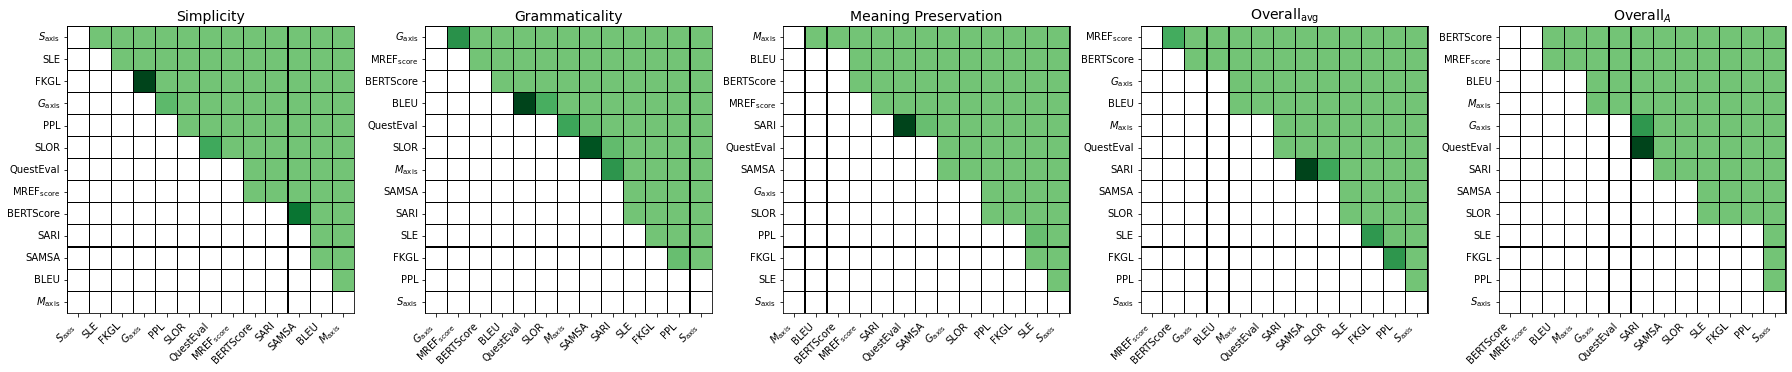

In [46]:
split_to_plot = 'all'
test_set_to_plot = 'hsplit'

metric_name = {
    'QuestEval': 'QuestEval',
    'sle': 'SLE',
    'bertscore_F1': 'BERTScore',
    'fkgl': 'FKGL',
    'bleu': 'BLEU',
    'sari': 'SARI',
    'samsa': 'SAMSA',
    'PPL': 'PPL',
    'SLOR': 'SLOR',
    'S_axis': r'$S_{\mathrm{axis}}$',
    'M_axis': r'$M_{\mathrm{axis}}$',
    'G_axis': r'$G_{\mathrm{axis}}$',
    'Mref_score': r'$\mathrm{MREF}_{\mathrm{score}}$'
}

aspect_name = {
    'simplicity': 'Simplicity',
    'grammaticality': 'Grammaticality',
    'meaning': 'Meaning Preservation',
    'overall_avg': r'Overall$_{\mathrm{avg}}$',
    'overall_A': r'Overall$_A$'
}

aspects = ['simplicity', 'grammaticality', 'meaning', 'overall_avg', 'overall_A']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

i = 0

for (split, aspect, test_set), (_, df_sig) in pearson_sentence_level.items():

    if split == split_to_plot and test_set == test_set_to_plot and aspect in aspects:
        
        ax = axes[i]

        # Rename metric labels in both rows and columns
        df_sig_plot = df_sig.rename(index=metric_name, columns=metric_name)

        x = sns.heatmap(
            df_sig_plot,
            yticklabels=True,
            xticklabels=True,
            cmap="Greens",
            center=0.00,
            linewidth=0.1,
            cbar=False,
            robust=False,
            square=True,
            ax=ax,
            linecolor='black'
        )

        # Show all borders
        for spine in x.spines.values():
            spine.set_visible(True)

        ax.set_title(aspect_name[aspect], fontsize=14)

        # Improve tick-label readability
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

        i += 1

        if i == 5:
            break

plt.tight_layout()
plt.savefig('significance_quality_sentence_level_complete.pdf', dpi=300, bbox_inches='tight')
plt.show()

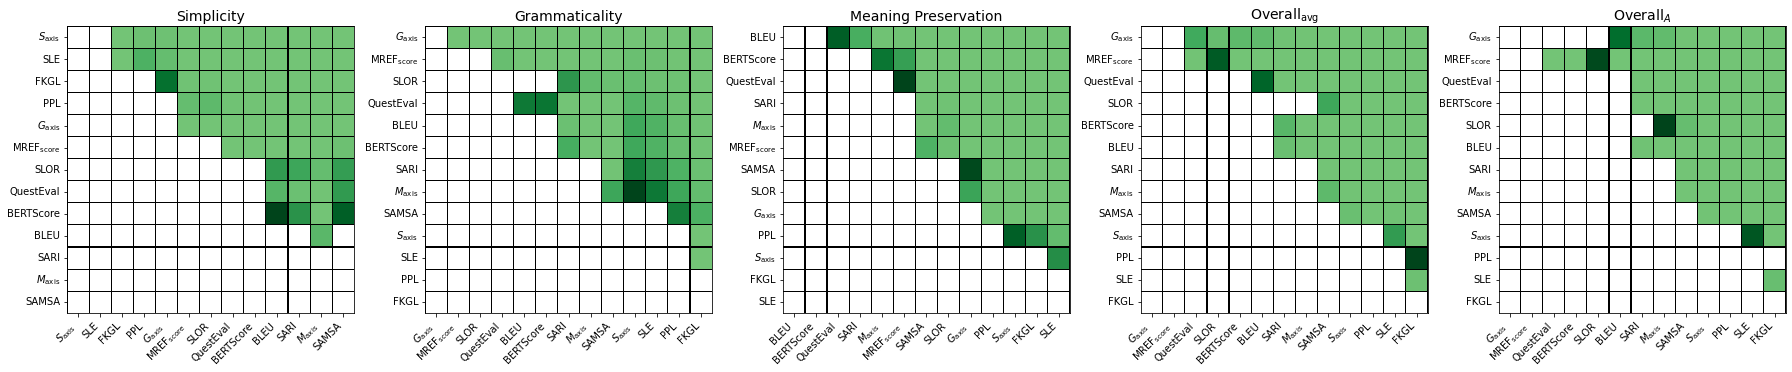

In [47]:
split_to_plot = 'all'
test_set_to_plot = 'hsplit'

metric_name = {
    'QuestEval': 'QuestEval',
    'sle': 'SLE',
    'bertscore_F1': 'BERTScore',
    'fkgl': 'FKGL',
    'bleu': 'BLEU',
    'sari': 'SARI',
    'samsa': 'SAMSA',
    'PPL': 'PPL',
    'SLOR': 'SLOR',
    'S_axis': r'$S_{\mathrm{axis}}$',
    'M_axis': r'$M_{\mathrm{axis}}$',
    'G_axis': r'$G_{\mathrm{axis}}$',
    'Mref_score': r'$\mathrm{MREF}_{\mathrm{score}}$'
}

aspect_name = {
    'simplicity': 'Simplicity',
    'grammaticality': 'Grammaticality',
    'meaning': 'Meaning Preservation',
    'overall_avg': r'Overall$_{\mathrm{avg}}$',
    'overall_A': r'Overall$_A$'
}

aspects = ['simplicity', 'grammaticality', 'meaning', 'overall_avg', 'overall_A']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

i = 0

for (split, aspect, test_set), (_, df_sig) in pearson_system_level.items():

    if split == split_to_plot and test_set == test_set_to_plot and aspect in aspects:
        
        ax = axes[i]

        # Rename metric labels in both rows and columns
        df_sig_plot = df_sig.rename(index=metric_name, columns=metric_name)

        x = sns.heatmap(
            df_sig_plot,
            yticklabels=True,
            xticklabels=True,
            cmap="Greens",
            center=0.00,
            linewidth=0.1,
            cbar=False,
            robust=False,
            square=True,
            ax=ax,
            linecolor='black'
        )

        # Show all borders
        for spine in x.spines.values():
            spine.set_visible(True)

        ax.set_title(aspect_name[aspect], fontsize=14)

        # Improve tick-label readability
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

        i += 1

        if i == 5:
            break

plt.tight_layout()
plt.savefig('significance_quality_system_level_complete.pdf', dpi=300, bbox_inches='tight')
plt.show()

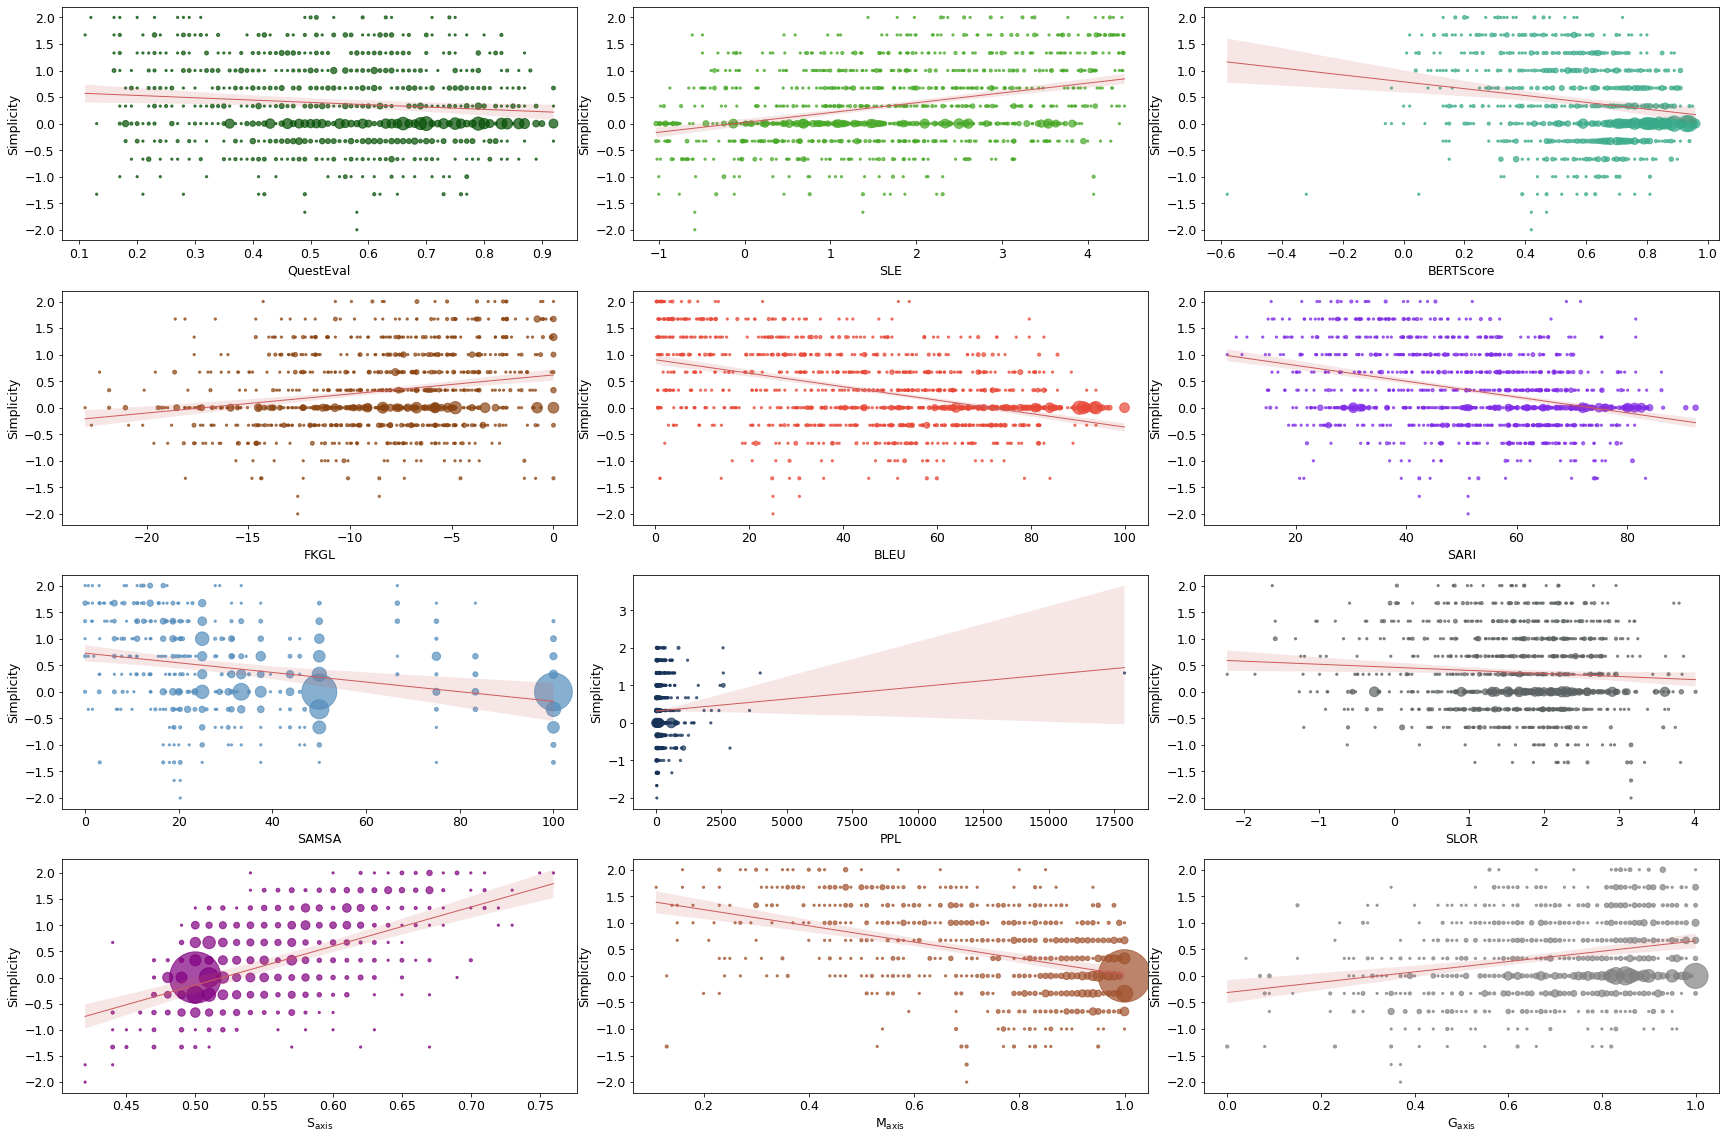

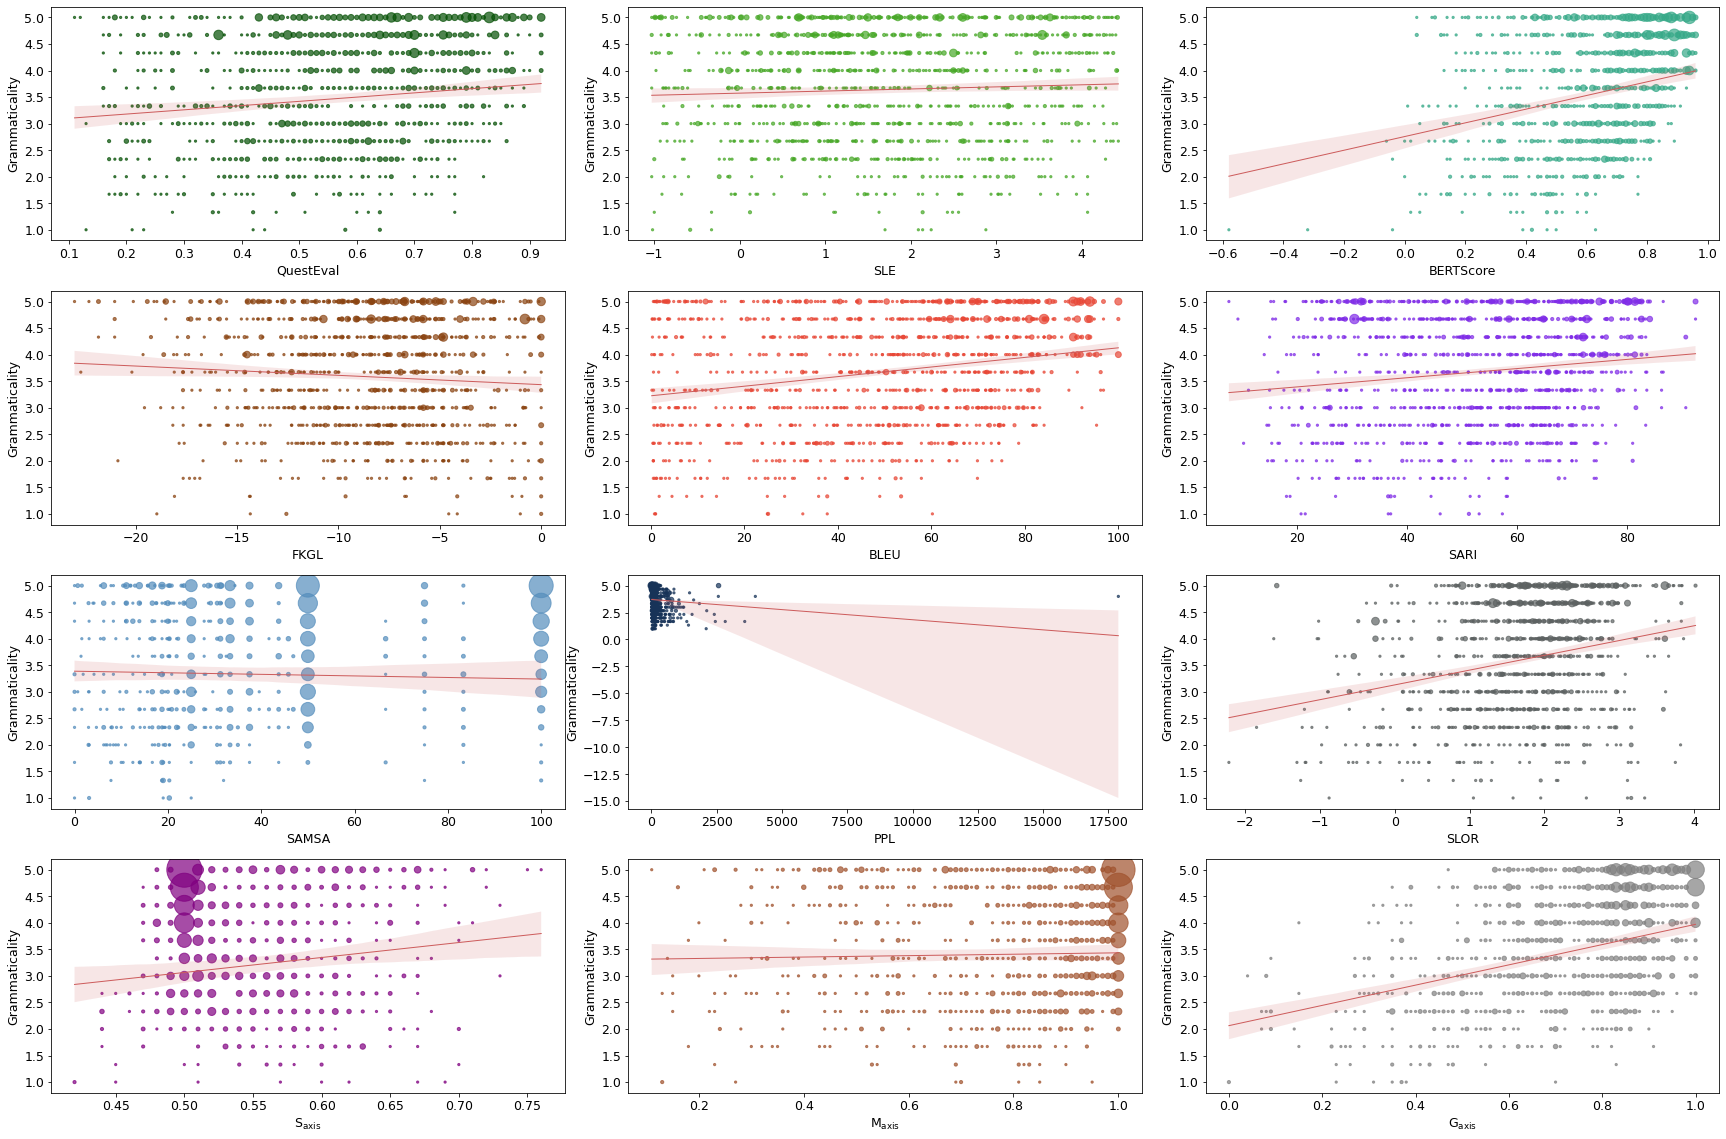

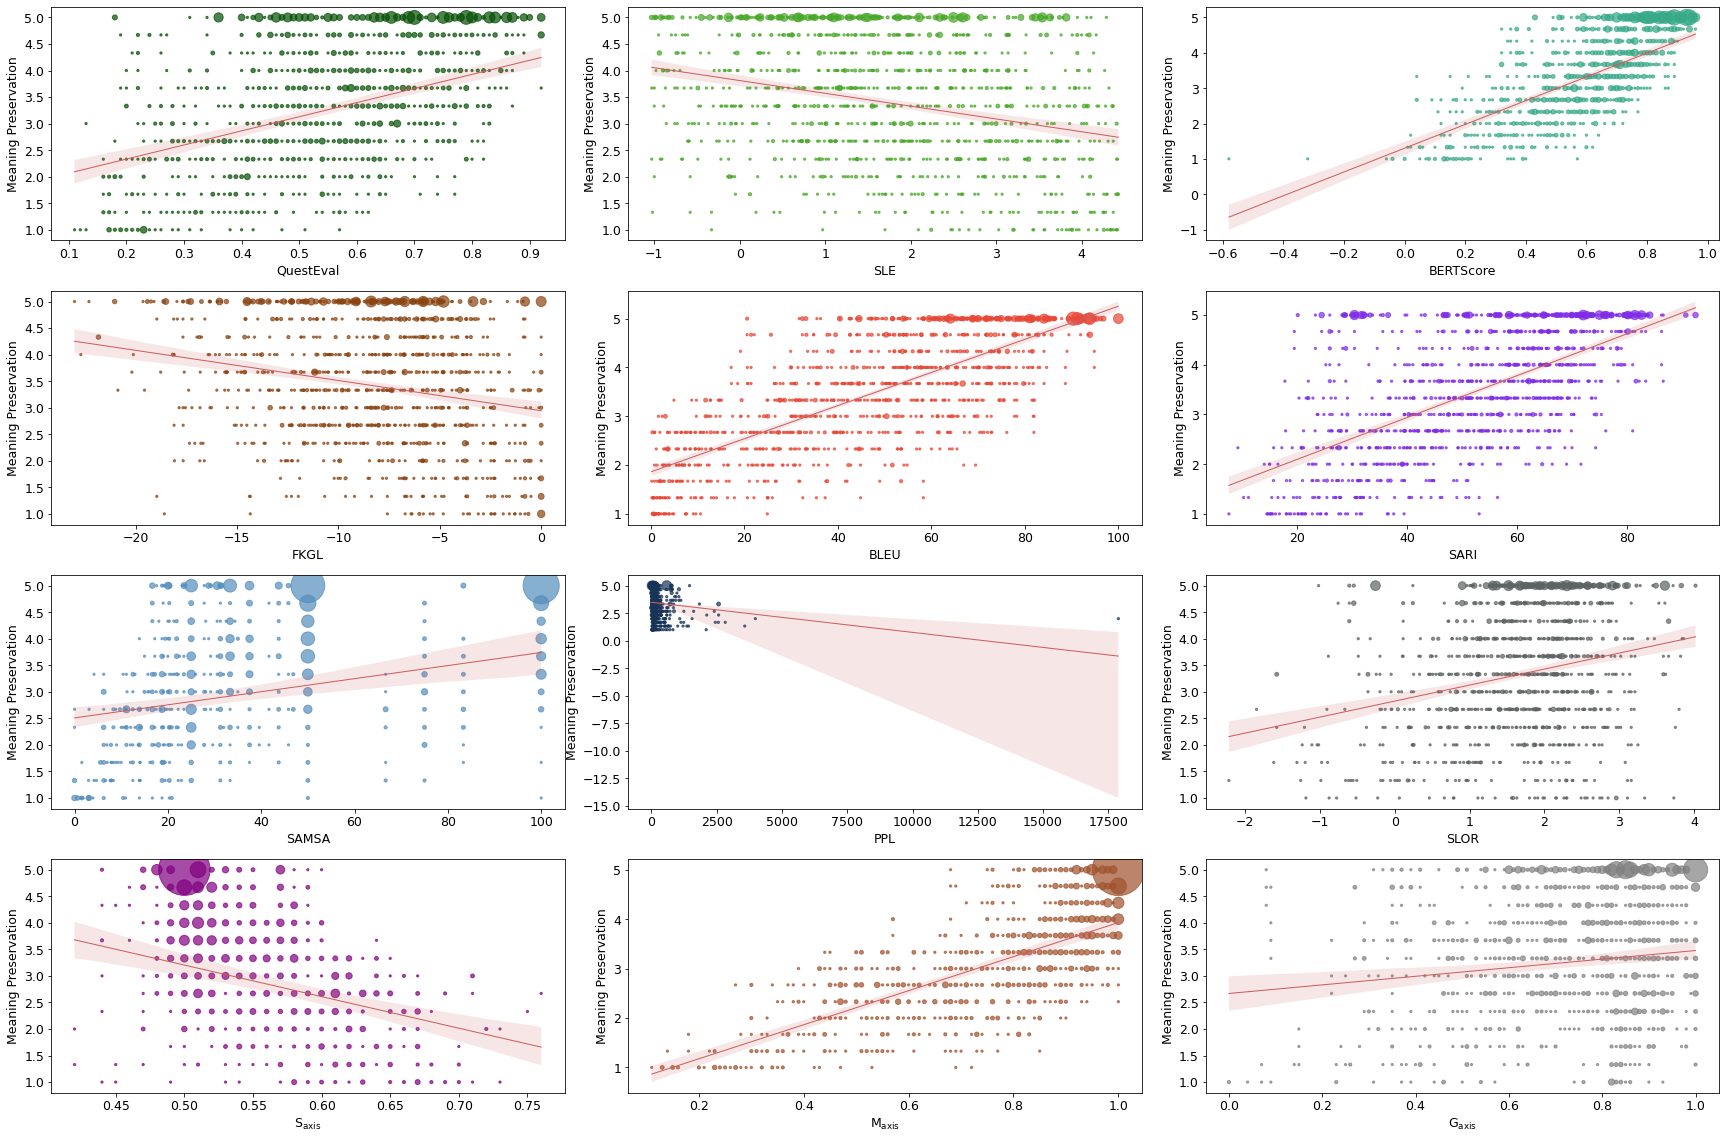

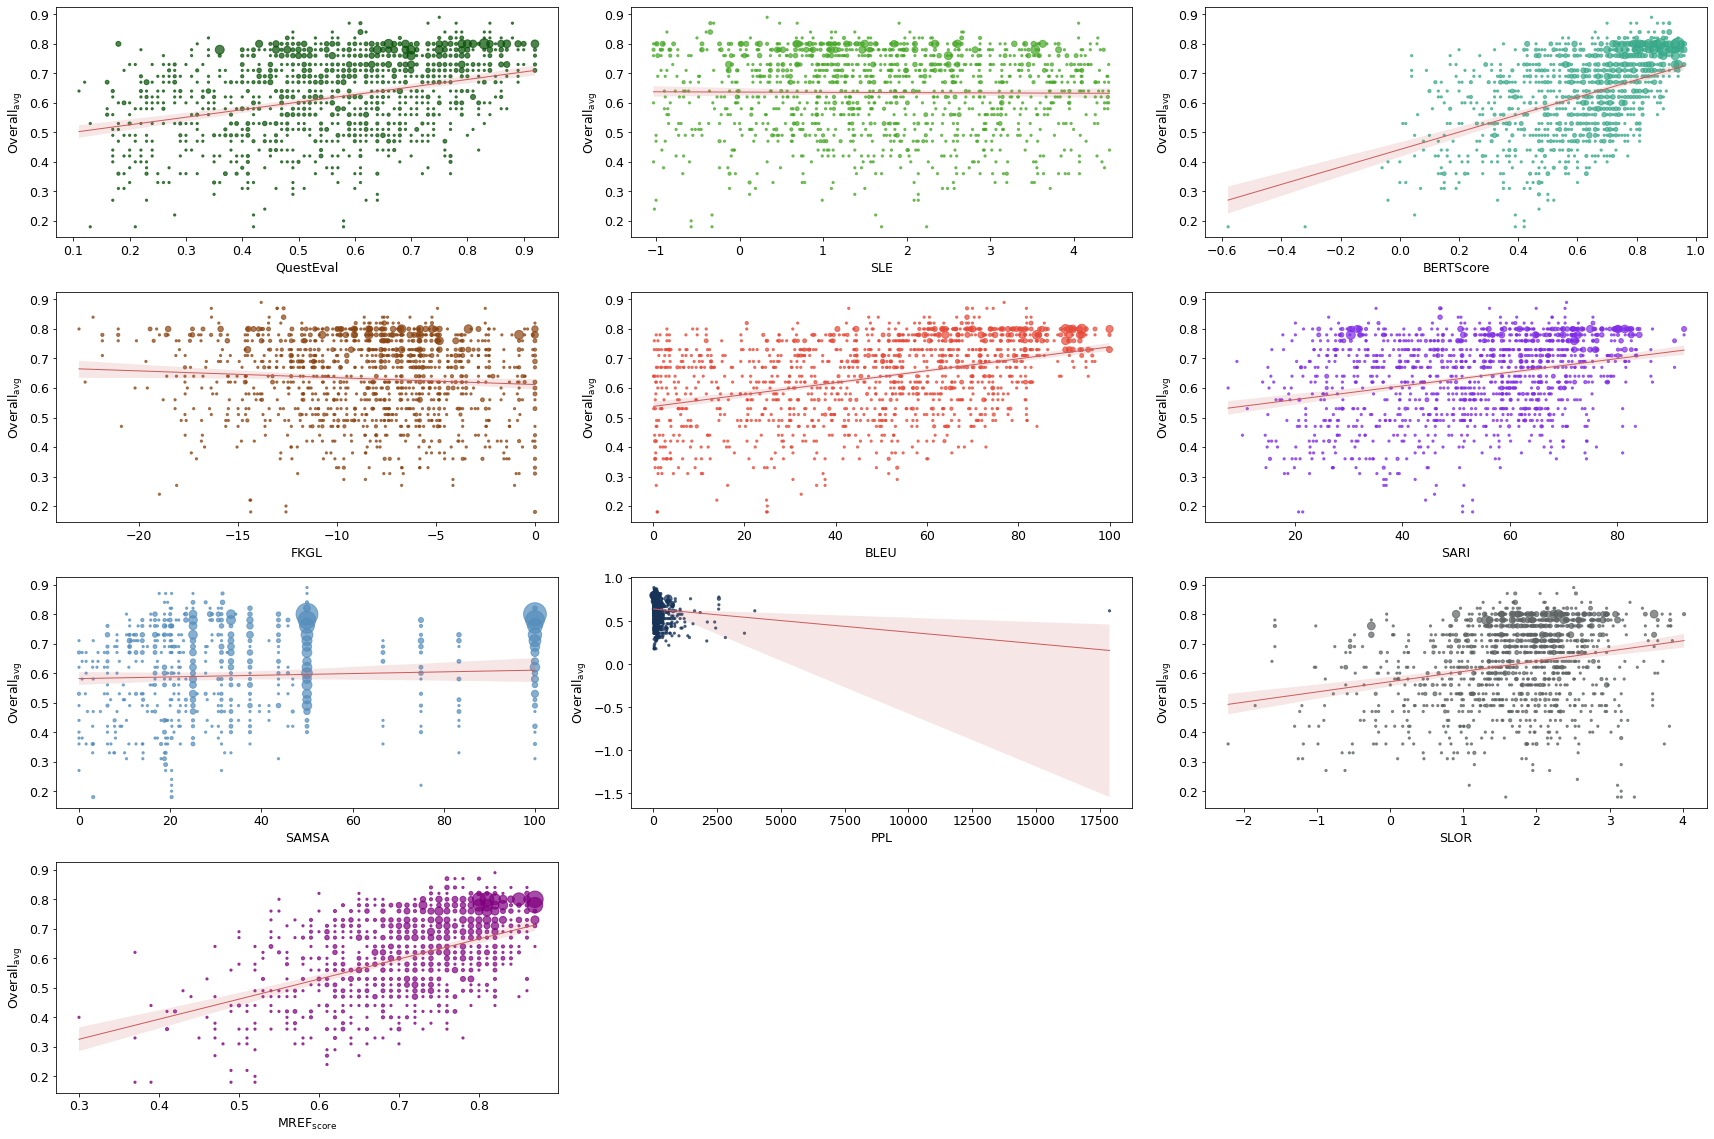

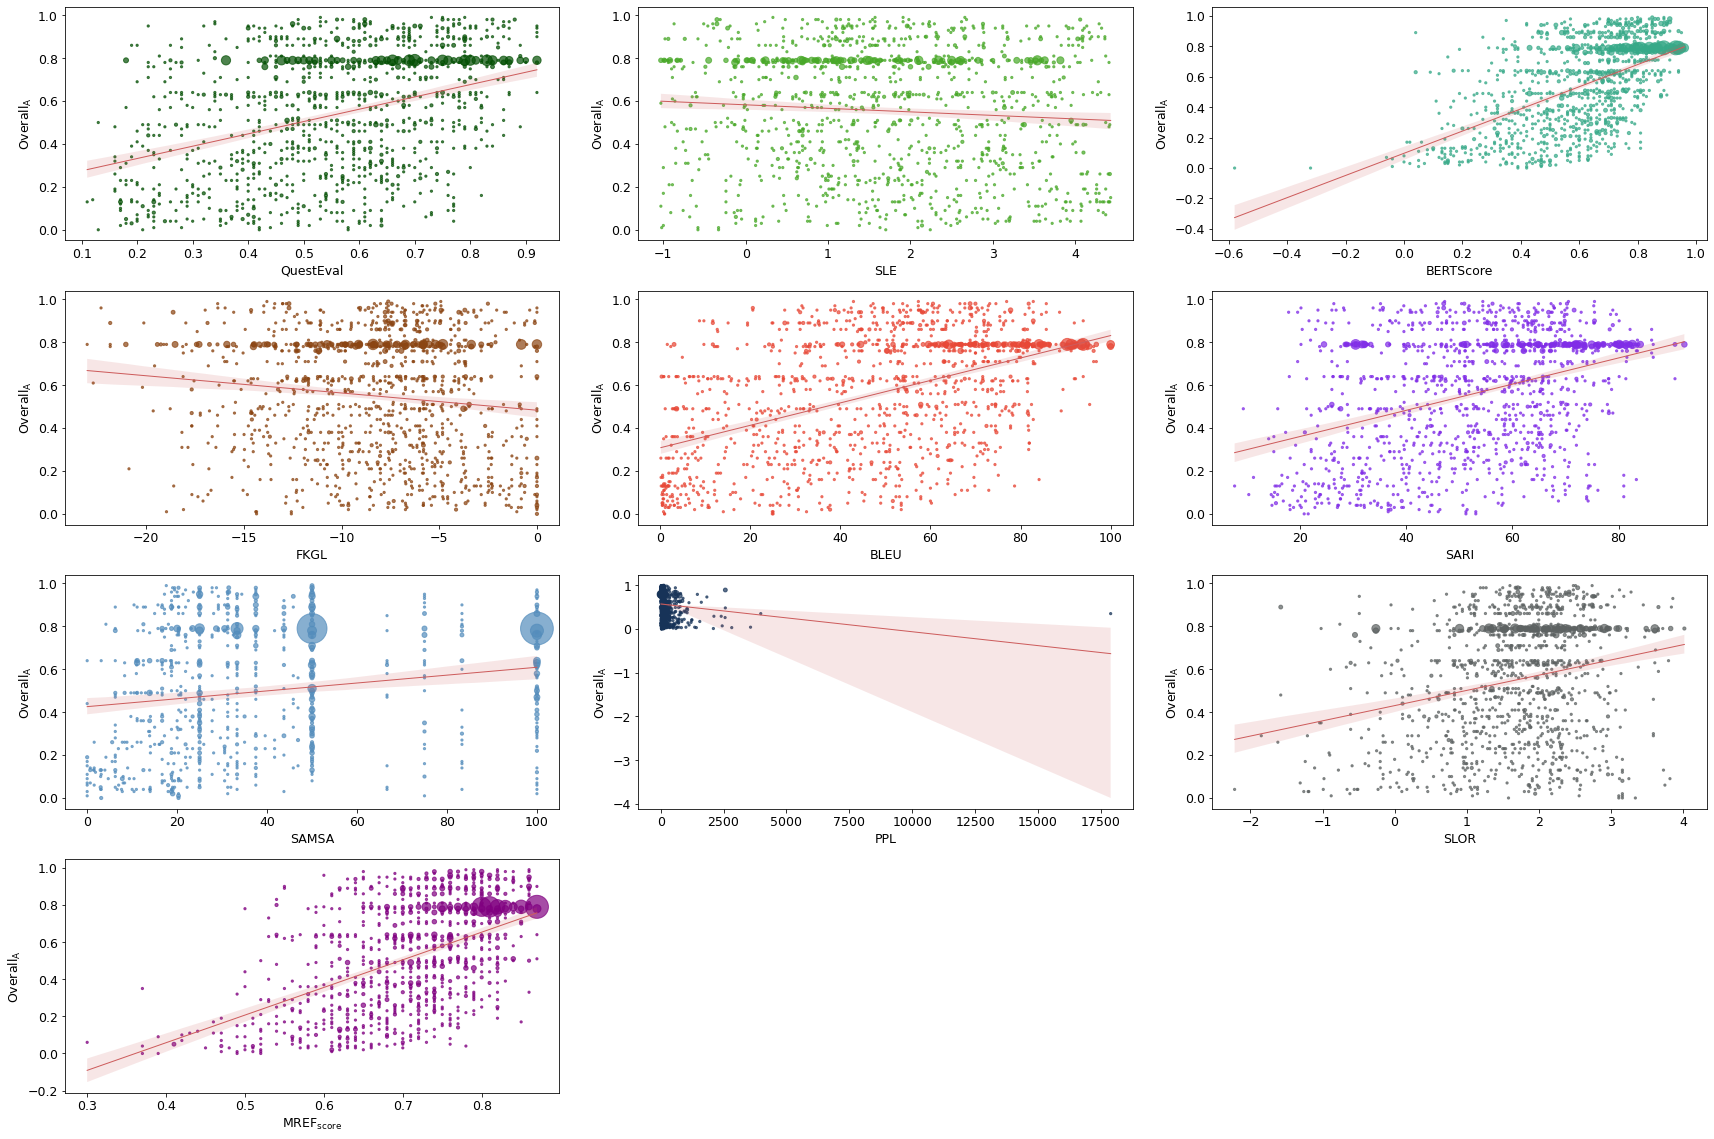

In [48]:
split_to_plot = 'all'
test_set_to_plot = 'hsplit'

metric_name = {
    'QuestEval': 'QuestEval',
    'sle': 'SLE',
    'bertscore_F1': 'BERTScore',
    'fkgl': 'FKGL',
    'bleu': 'BLEU',
    'sari': 'SARI',
    'samsa': 'SAMSA',
    'PPL': 'PPL',
    'SLOR': 'SLOR',
    'S_axis': r'$S_{\mathrm{axis}}$',
    'M_axis': r'$M_{\mathrm{axis}}$',
    'G_axis': r'$G_{\mathrm{axis}}$',
    'Mref_score': r'$\mathrm{MREF}_{\mathrm{score}}$'
}

aspect_name = {
    'simplicity': 'Simplicity',
    'grammaticality': 'Grammaticality',
    'meaning': 'Meaning Preservation',
    'overall_avg': r'Overall$_{\mathrm{avg}}$',
    'overall_A': r'Overall$_A$'
}

metrics = {
    'simplicity': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'S_axis', 'M_axis', 'G_axis'
    ],
    'grammaticality': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'S_axis', 'M_axis', 'G_axis'
    ],
    'meaning': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'S_axis', 'M_axis', 'G_axis'
    ],
    'overall_avg': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'Mref_score'
    ],
    'overall_A': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'Mref_score'
    ],
}

colors = [
    "#034F03", "#48A828", "#36A988", "#8B4513",
    "#E84837", "#802DE7", "#548DBC", "#173358",
    "#5D6262", "purple", "sienna", "gray"
]

line_kws = {
    'color': 'indianred',
    'linestyle': '-',
    'linewidth': 1
}

plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams.update({'font.size': 12.5})

for aspect in ['simplicity', 'grammaticality', 'meaning', 'overall_avg', 'overall_A']:

    fig, axes = plt.subplots(4, 3, figsize=(24, 16))
    axes = axes.flat

    for i, (metric, color) in enumerate(zip(metrics[aspect], colors)):

        ax = axes[i]

        auto_scores = df_metrics_sentence_level[
            df_metrics_sentence_level['test_set'] == test_set_to_plot
        ][['sent_id', 'sys_name', metric]]

        df_human_scores = df_sentence_level[
            ['sent_id', 'sys_name', aspect]
        ].sort_values(by=[aspect])

        df_aux = pd.merge(
            auto_scores,
            df_human_scores,
            on=['sent_id', 'sys_name']
        ).dropna(subset=[metric, aspect])

        # Collapse overlapping/near-overlapping points into larger markers
        pairs = [
            [round(x, 2), round(y, 2)]
            for x, y in zip(df_aux[metric], df_aux[aspect])
        ]

        unique_pairs = []
        size = []
        x_data = []
        y_data = []

        for p in pairs:
            if p not in unique_pairs:
                unique_pairs.append(p)
                size.append(5 * pairs.count(p))
                x_data.append(p[0])
                y_data.append(p[1])

        scatter_kws = {
            'marker': 'o',
            'alpha': 0.7,
            's': size
        }

        sns.regplot(
            x=x_data,
            y=y_data,
            scatter=True,
            ax=ax,
            line_kws=line_kws,
            scatter_kws=scatter_kws,
            color=color
        )

        ax.set_xlabel(metric_name.get(metric, metric))
        ax.set_ylabel(aspect_name.get(aspect, aspect))

    # Hide unused subplots, especially for overall_avg and overall_A
    for j in range(len(metrics[aspect]), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        f'{aspect}_sentence_level.pdf',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

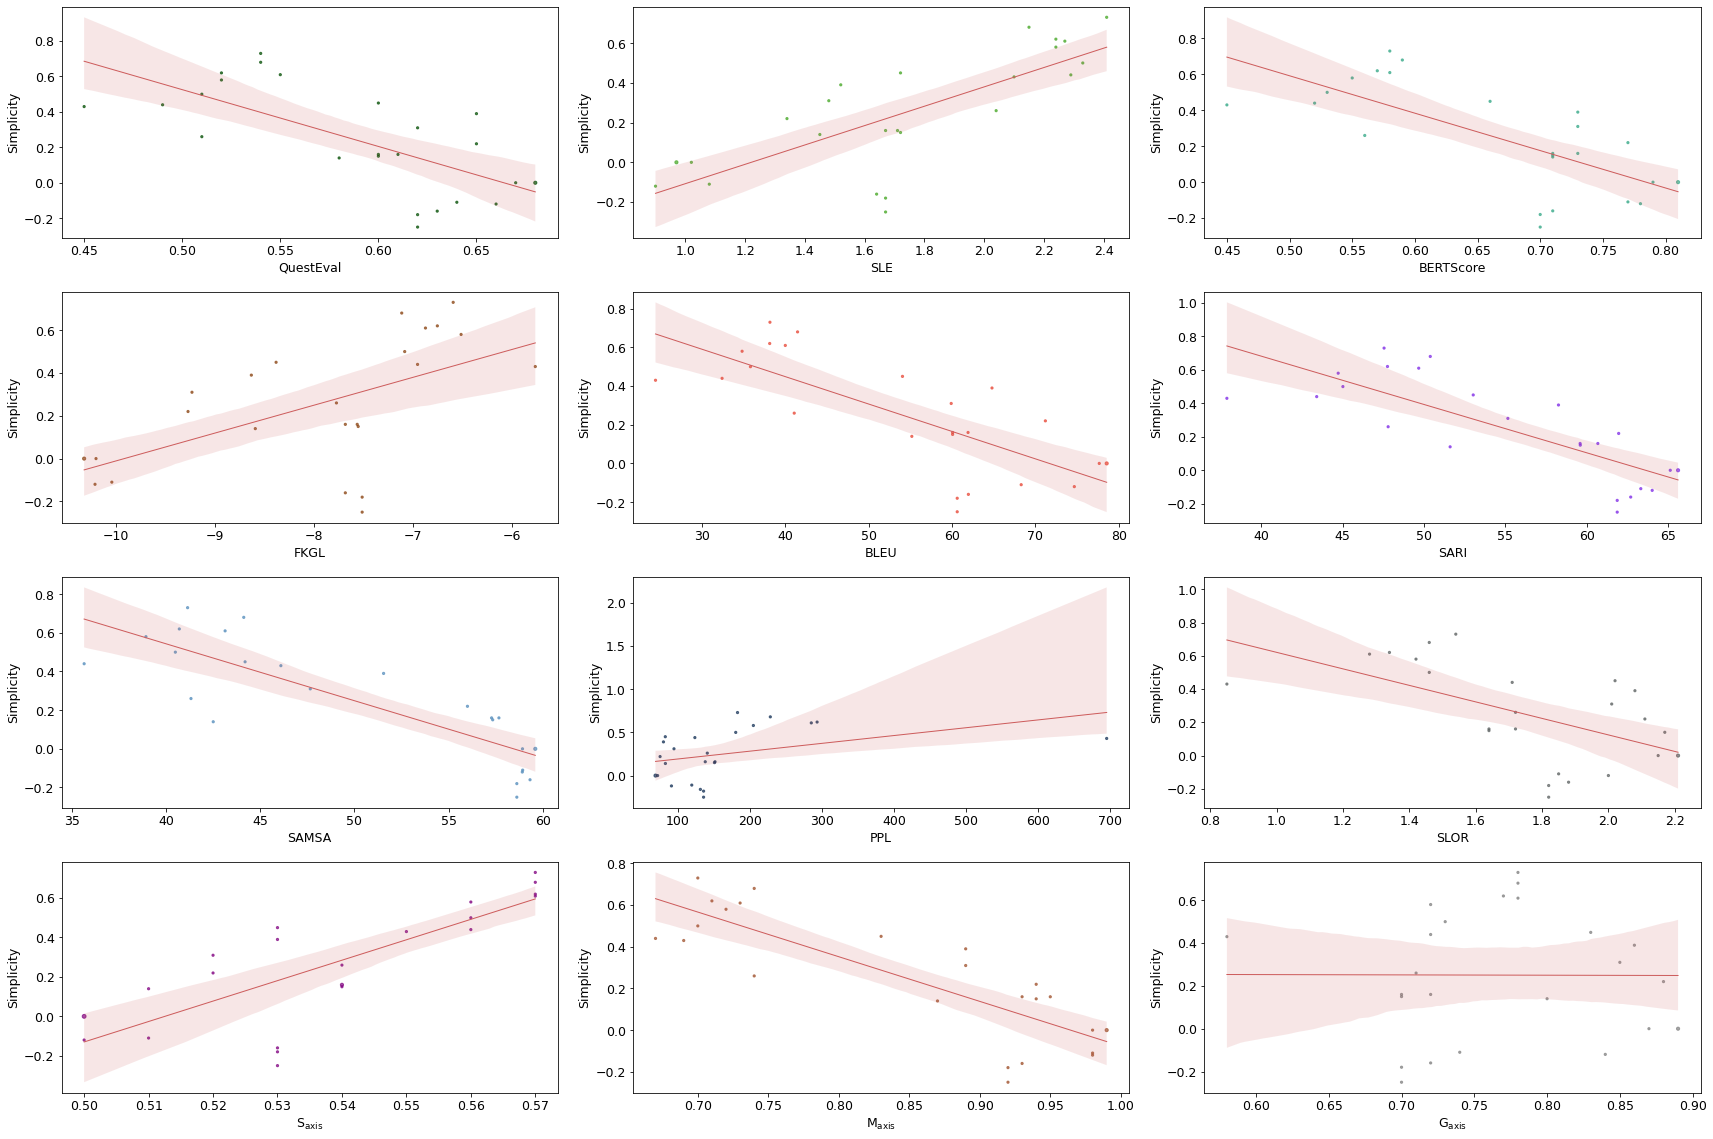

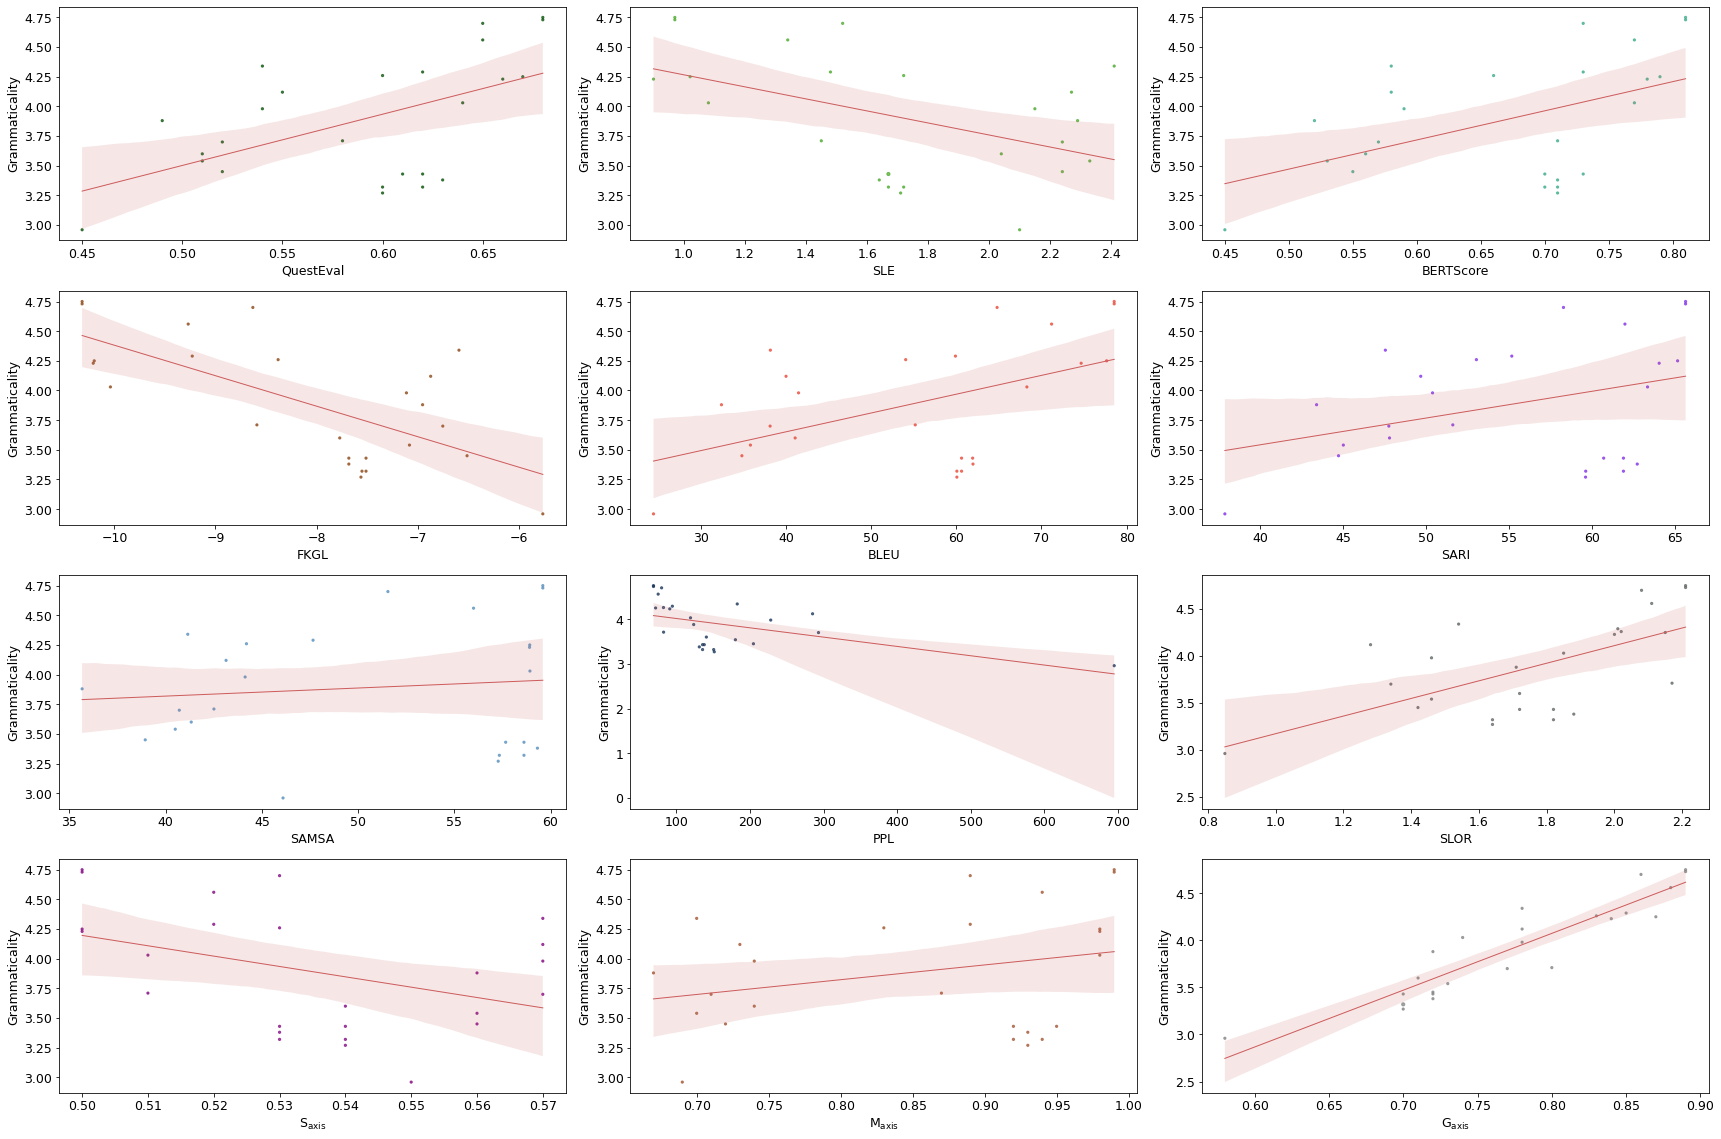

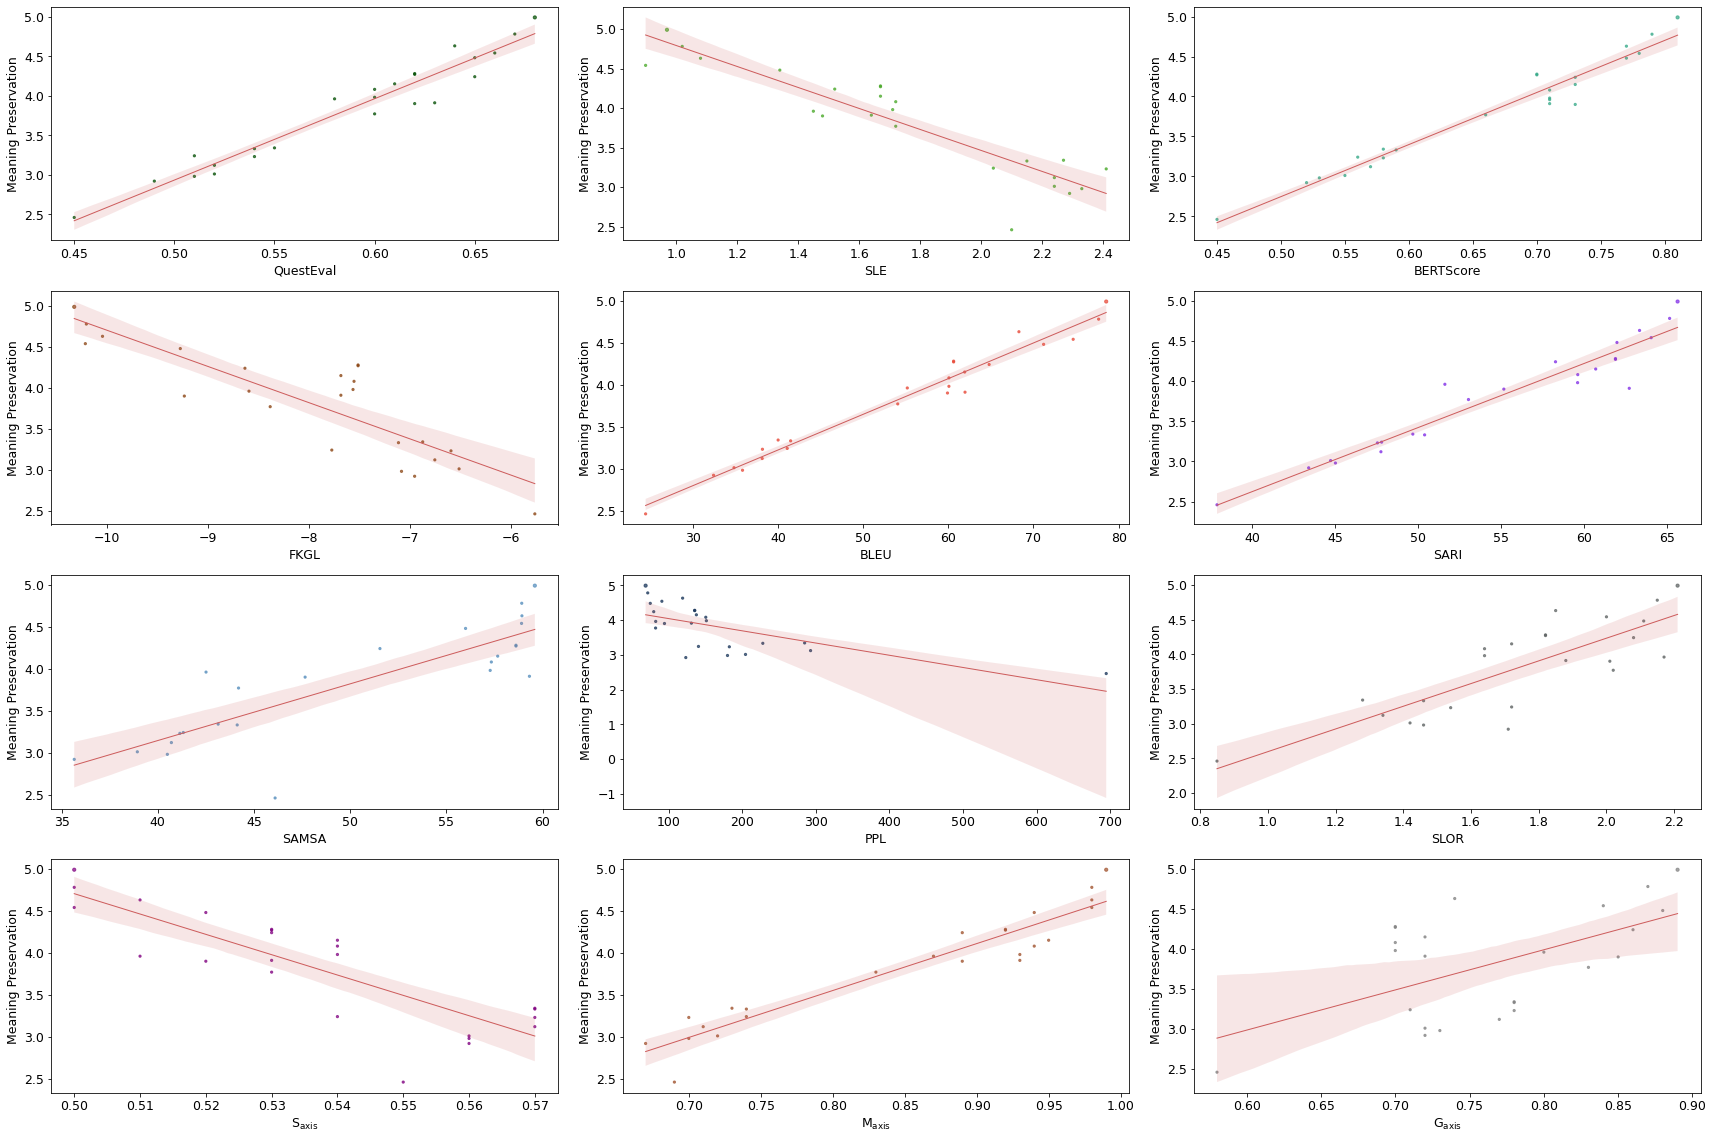

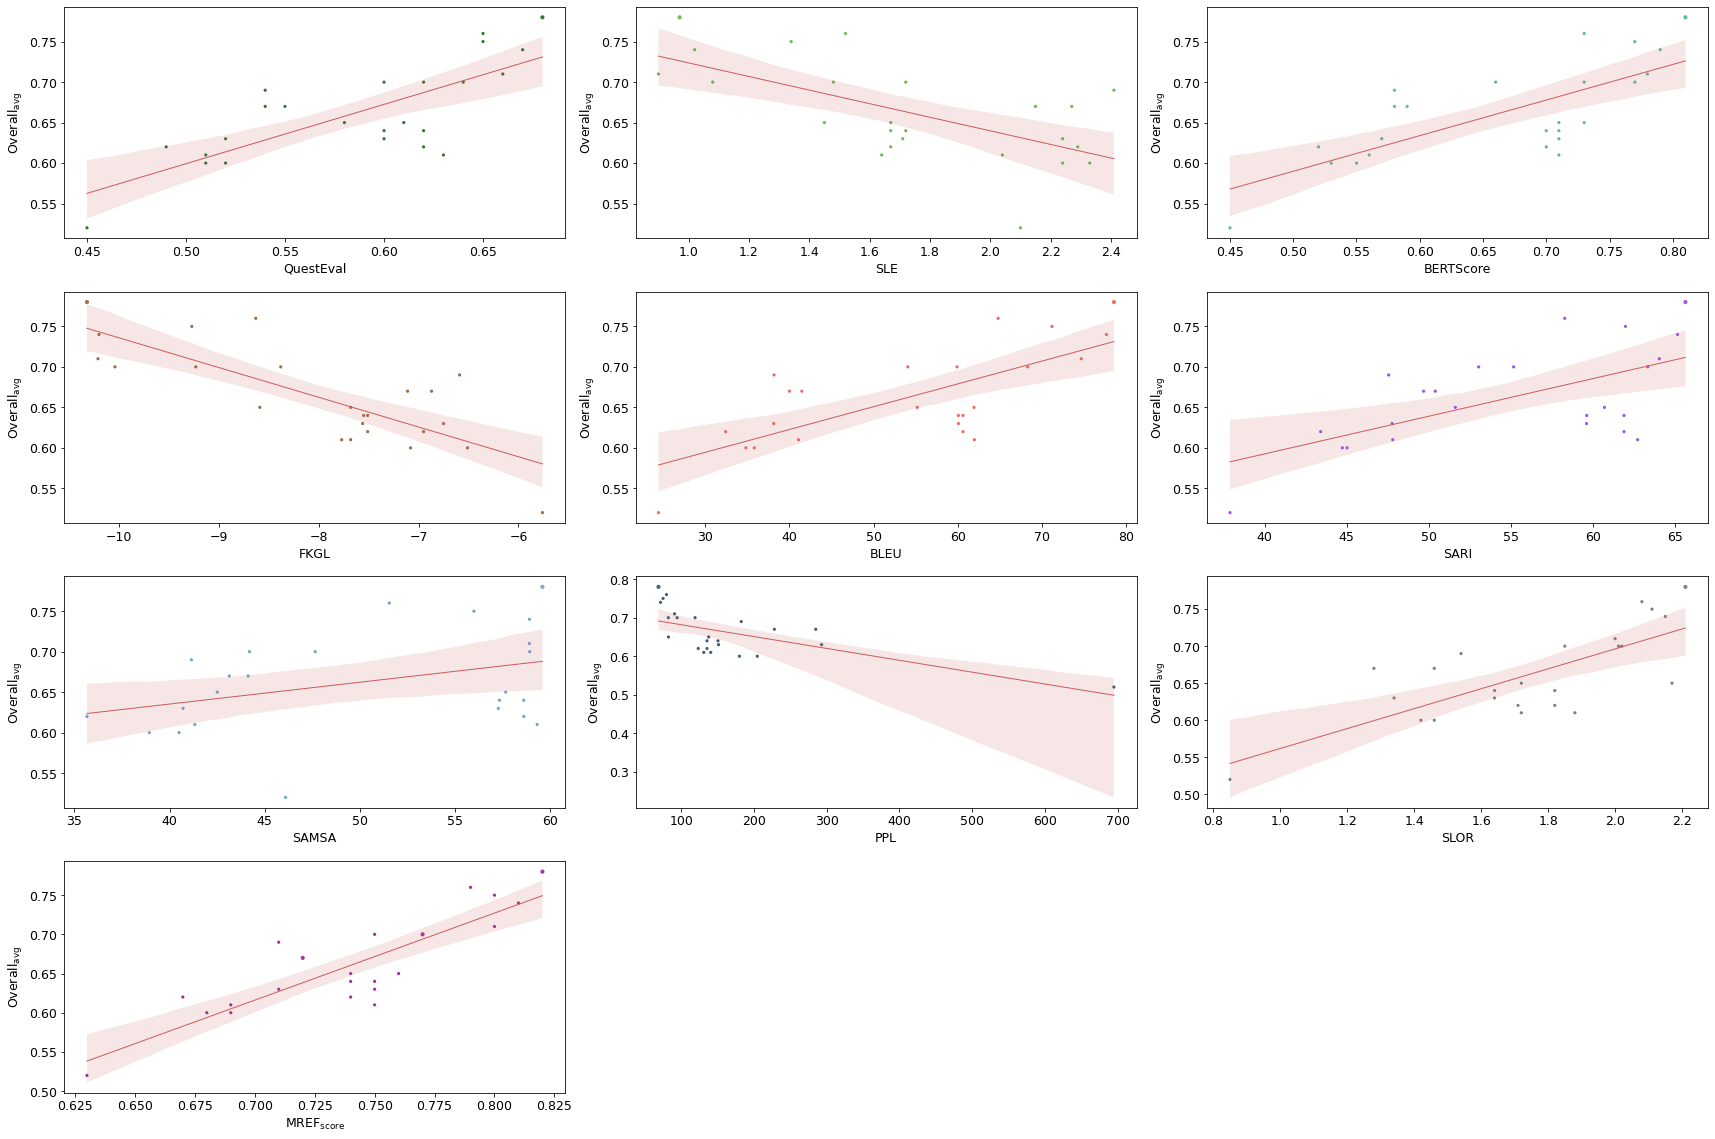

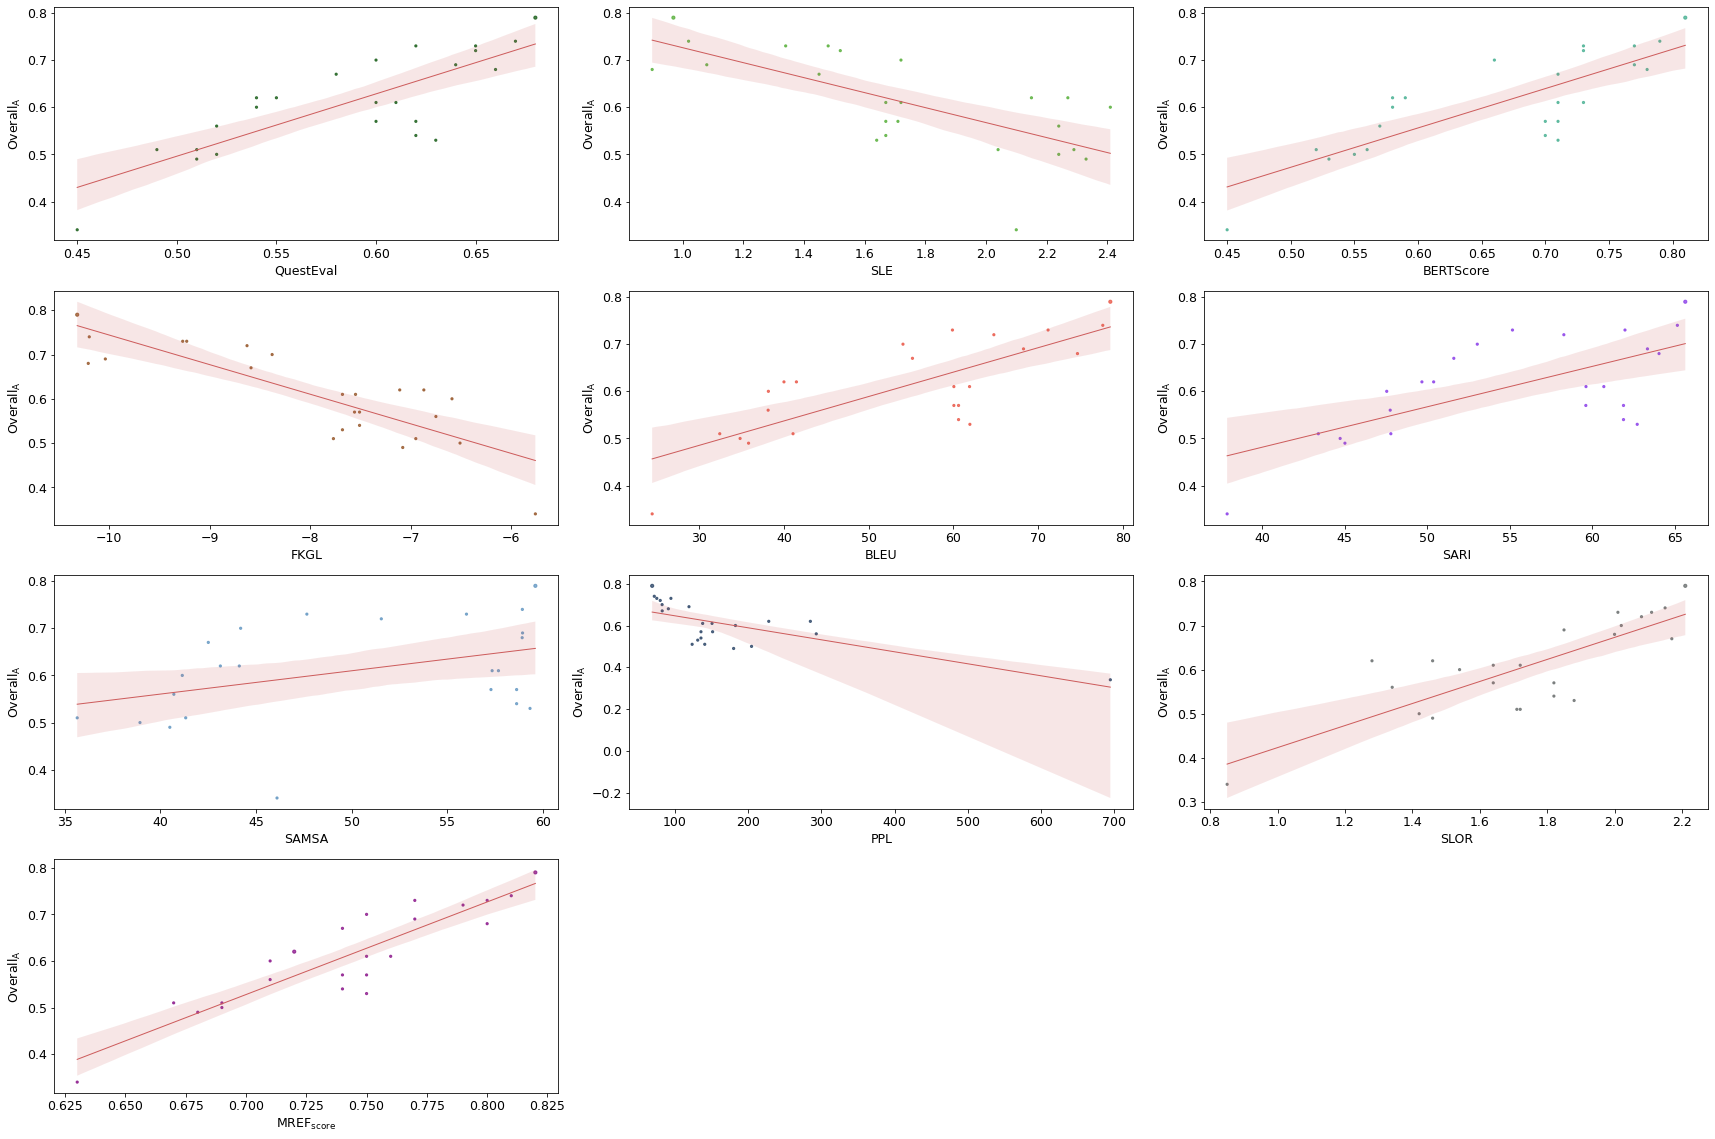

In [49]:
split_to_plot = 'all'
test_set_to_plot = 'hsplit'

metric_name = {
    'QuestEval': 'QuestEval',
    'sle': 'SLE',
    'bertscore_F1': 'BERTScore',
    'fkgl': 'FKGL',
    'bleu': 'BLEU',
    'sari': 'SARI',
    'samsa': 'SAMSA',
    'PPL': 'PPL',
    'SLOR': 'SLOR',
    'S_axis': r'$S_{\mathrm{axis}}$',
    'M_axis': r'$M_{\mathrm{axis}}$',
    'G_axis': r'$G_{\mathrm{axis}}$',
    'Mref_score': r'$\mathrm{MREF}_{\mathrm{score}}$'
}

aspect_name = {
    'simplicity': 'Simplicity',
    'grammaticality': 'Grammaticality',
    'meaning': 'Meaning Preservation',
    'overall_avg': r'Overall$_{\mathrm{avg}}$',
    'overall_A': r'Overall$_A$'
}

metrics = {
    'simplicity': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'S_axis', 'M_axis', 'G_axis'
    ],
    'grammaticality': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'S_axis', 'M_axis', 'G_axis'
    ],
    'meaning': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'S_axis', 'M_axis', 'G_axis'
    ],
    'overall_avg': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'Mref_score'
    ],
    'overall_A': [
        'QuestEval', 'sle', 'bertscore_F1', 'fkgl', 'bleu', 'sari',
        'samsa', 'PPL', 'SLOR', 'Mref_score'
    ],
}

colors = [
    "#034F03", "#48A828", "#36A988", "#8B4513",
    "#E84837", "#802DE7", "#548DBC", "#173358",
    "#5D6262", "purple", "sienna", "gray"
]

line_kws = {
    'color': 'indianred',
    'linestyle': '-',
    'linewidth': 1
}

plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams.update({'font.size': 12.5})

for aspect in ['simplicity', 'grammaticality', 'meaning', 'overall_avg', 'overall_A']:

    fig, axes = plt.subplots(4, 3, figsize=(24, 16))
    axes = axes.flat

    for i, (metric, color) in enumerate(zip(metrics[aspect], colors)):

        ax = axes[i]

        auto_scores = df_metrics_system_level[
            df_metrics_system_level['test_set'] == test_set_to_plot
        ][['sent_id', 'sys_name', metric]]

        df_human_scores = df_system_level[
            ['sent_id', 'sys_name', aspect]
        ].sort_values(by=[aspect])

        df_aux = pd.merge(
            auto_scores,
            df_human_scores,
            on=['sent_id', 'sys_name']
        ).dropna(subset=[metric, aspect])

        # Collapse overlapping/near-overlapping points into larger markers
        pairs = [
            [round(x, 2), round(y, 2)]
            for x, y in zip(df_aux[metric], df_aux[aspect])
        ]

        unique_pairs = []
        size = []
        x_data = []
        y_data = []

        for p in pairs:
            if p not in unique_pairs:
                unique_pairs.append(p)
                size.append(5 * pairs.count(p))
                x_data.append(p[0])
                y_data.append(p[1])

        scatter_kws = {
            'marker': 'o',
            'alpha': 0.7,
            's': size
        }

        sns.regplot(
            x=x_data,
            y=y_data,
            scatter=True,
            ax=ax,
            line_kws=line_kws,
            scatter_kws=scatter_kws,
            color=color
        )

        ax.set_xlabel(metric_name.get(metric, metric))
        ax.set_ylabel(aspect_name.get(aspect, aspect))

    # Hide unused subplots, especially for overall_avg and overall_A
    for j in range(len(metrics[aspect]), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        f'{aspect}_system_level.pdf',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()